In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

# 1. 패키지로드 & 한글설정 & 경고메세지 ignore

In [3]:
# 패키지 import
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 시각화의 선명도를 높임
%config InlineBackend.figure_format = "retina"
# from IPython.display import set_matplotlib_formats
# set_matplotlib_formats('retina')

# 다른 폰트를 기본으로 하려면
# from matplotlib.font_manager import FontProperties, fontManager
# font_path = 'data/font/온글잎밑미.ttf'
# #font_path = "c:/Windows/Fonts/H2PORM.TTF"
# fontproperties = FontProperties(fname=font_path, size=30)
# fontManager.addfont(file_path) # windows폴더에 있지 않는 ttf파일일 경우 
# font_name = fontproperties.get_name()

# 한글설정 및 미적속성 설정
sns.set(style='white',
       context='notebook',
       palette='Dark2',
       rc={'figure.figsize': (12,3),
           'font.family':'Malgun Gothic',
           # font.family':font_nama,
           #'font.size':20,
           'axes.unicode_minus':False})

# warning(경고) 안보이게
import warnings
# warnings.filterwarnings(action='ignore') # 경고 메세지 안보이게
# warnings.filterwarnings(action='default') # 경고 메세지 보이게

# 2. 데이터 다운받아, 서울과 부산데이터만 df변수에 읽어온다

In [17]:
# 서울시 소상공인 데이터(warning 해결방법1)
df_seoul=pd.read_csv('c:/ai/downloads/shareData/상가정보/소상공인시장진흥공단_상가(상권)정보_서울_202603.csv',
                     low_memory=False) #파일전체를 한번에 읽어서 타입을 일관되게 추론

In [26]:
# 서울시 소상공인 데이터(warning 해결방법2)
df_seoul=pd.read_csv('c:/ai/downloads/shareData/상가정보/소상공인시장진흥공단_상가(상권)정보_서울_202603.csv',
                     dtype={'층정보':str}
                    )

In [18]:
df_seoul.shape

(537489, 39)

In [23]:
#정확한 메모리 사용량
df_seoul.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537489 entries, 0 to 537488
Data columns (total 39 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   상가업소번호     537489 non-null  object 
 1   상호명        537489 non-null  object 
 2   지점명        47001 non-null   object 
 3   상권업종대분류코드  537489 non-null  object 
 4   상권업종대분류명   537489 non-null  object 
 5   상권업종중분류코드  537489 non-null  object 
 6   상권업종중분류명   537489 non-null  object 
 7   상권업종소분류코드  537489 non-null  object 
 8   상권업종소분류명   537489 non-null  object 
 9   표준산업분류코드   537291 non-null  object 
 10  표준산업분류명    537291 non-null  object 
 11  시도코드       537489 non-null  int64  
 12  시도명        537489 non-null  object 
 13  시군구코드      537489 non-null  int64  
 14  시군구명       537489 non-null  object 
 15  행정동코드      537489 non-null  int64  
 16  행정동명       537489 non-null  object 
 17  법정동코드      537489 non-null  int64  
 18  법정동명       537489 non-null  object 
 19  지번코드       537489 non-n

In [24]:
df_seoul['층정보'].unique()

array(['1', nan, '2', '3', '20', '5', '9', '4', '8', '6', '지', '24', '14',
       '402', '10', '12', '7', '17', '13', '18', 'B1', '15', '30', '11',
       '28', '101', '104', '16', '19', '35', '303', '21', '23', '1502',
       '43', '29', 'B2', '190', '502', '102', '401', '22', '221', '25',
       '42', 'B126', '136', '27', '33', '601', '36', 'B07', '반지층', '905',
       '34', '114', '37', '04', '01', '26', '39', '50', 'B17', '202',
       '201', 'B203', '32', '68', '487', '05', '309', '842', '498', 'B3',
       'B4', '38', '41', '31', '45', '704', '301', '207', '960', '46',
       '403', '705', '06', '48', '8279', '2173', '08', '55', '310', '105',
       '02', '40', '109', '03', '302', '1117', '408', '반', '0', '030',
       '53', '1005', 'B307', '311', '1404', '52', '204', '410', '5112',
       '100', '242', '1201', '1401', '151', '701', '407', '103', '1909',
       '203', 'B40', '62', '716', '511', '1402', '308', '510', '305',
       '1904', '4559', '1111', '1107', '110', '44', '1013'

In [27]:
df_seoul.head(1).T

,0
상가업소번호,MA010120220800800619
상호명,참편한공인중개사사무소
지점명,NaN
상권업종대분류코드,L1
상권업종대분류명,부동산
상권업종중분류코드,L102
상권업종중분류명,부동산 서비스
상권업종소분류코드,L10203
상권업종소분류명,부동산 중개/대리업
표준산업분류코드,L68221


In [28]:
#부산 소상공인 데이터
df_busan=pd.read_csv('c:/ai/downloads/shareData/상가정보/소상공인시장진흥공단_상가(상권)정보_부산_202603.csv',
                     dtype={'층정보':str}
                    )

In [31]:
df_busan.head(1).T

,0
상가업소번호,MA010120220804863915
상호명,제이와이솔루션
지점명,NaN
상권업종대분류코드,G2
상권업종대분류명,소매
상권업종중분류코드,G215
상권업종중분류명,의약·화장품 소매
상권업종소분류코드,G21502
상권업종소분류명,의료기기 소매업
표준산업분류코드,G47812


In [ ]:
#서울소상공인데이터, 부산소상공인데이터 concat

In [40]:
# concat하기전 두데이터의 column 일치여부 먼저 확인
np.all(df_seoul.columns==df_busan.columns)

True

In [45]:
# concat하기전 두데이터의 column 타입들 확인
df_seoul.dtypes

상가업소번호        object
상호명           object
지점명           object
상권업종대분류코드     object
상권업종대분류명      object
상권업종중분류코드     object
상권업종중분류명      object
상권업종소분류코드     object
상권업종소분류명      object
표준산업분류코드      object
표준산업분류명       object
시도코드           int64
시도명           object
시군구코드          int64
시군구명          object
행정동코드          int64
행정동명          object
법정동코드          int64
법정동명          object
지번코드           int64
대지구분코드         int64
대지구분명         object
지번본번지        float64
지번부번지        float64
지번주소          object
도로명코드          int64
도로명           object
건물본번지        float64
건물부번지        float64
건물관리번호        object
건물명           object
도로명주소         object
구우편번호          int64
신우편번호          int64
동정보          float64
층정보           object
호정보          float64
경도           float64
위도           float64
dtype: object

In [48]:
df_busan.dtypes

상가업소번호        object
상호명           object
지점명           object
상권업종대분류코드     object
상권업종대분류명      object
상권업종중분류코드     object
상권업종중분류명      object
상권업종소분류코드     object
상권업종소분류명      object
표준산업분류코드      object
표준산업분류명       object
시도코드           int64
시도명           object
시군구코드          int64
시군구명          object
행정동코드          int64
행정동명          object
법정동코드          int64
법정동명          object
지번코드           int64
대지구분코드         int64
대지구분명         object
지번본번지        float64
지번부번지        float64
지번주소          object
도로명코드          int64
도로명           object
건물본번지          int64
건물부번지        float64
건물관리번호        object
건물명           object
도로명주소         object
구우편번호          int64
신우편번호          int64
동정보          float64
층정보           object
호정보          float64
경도           float64
위도           float64
dtype: object

In [62]:
result= df_seoul.dtypes==df_busan.dtypes
result[result== False]

Series([], dtype: bool)

In [63]:
#서울 건물본번지
print(df_seoul['건물본번지'].dtype)
print(df_seoul['건물본번지'][:3])


float64
0     25.0
1      8.0
2    385.0
Name: 건물본번지, dtype: float64


In [64]:
#부산 건물본번지
print(df_busan['건물본번지'].dtype)
print(df_busan['건물본번지'][:3])

float64
0     47.0
1    343.0
2     86.0
Name: 건물본번지, dtype: float64


In [55]:
df_busan['건물본번지']=df_busan['건물본번지'].astype('float')

In [56]:
df_busan['건물본번지'].dtype ==df_seoul['건물본번지'].dtype

True

In [65]:
df_seoul['건물본번지'].isna().sum()  #seoul 결측치 확인됨  결측치로 type float로 됨

2

In [66]:
df_busan['건물본번지'].isna().sum()  #seoul 결측치 확인안됨  결측치로 type float로 됨

0

In [71]:
#서울시 건물 본번지가 결측치인 데이터 추출
df_seoul.loc[df_seoul['건물본번지'].isna(),['상호명','건물본번지']]

,상호명,건물본번지
81807,명함이야기,NaN
176031,명함랜드기프트랜드,NaN


In [73]:
#concat
df=pd.concat([df_seoul,df_busan]) #axis=0 기본값
df.shape

(692592, 39)

In [78]:
df.loc[0,['상호명','시도명']]

,상호명,시도명
0,참편한공인중개사사무소,서울특별시
0,제이와이솔루션,부산광역시


In [79]:
#concat후 인덱스 정리
df=df.reset_index(drop=True)

In [81]:
df.loc[1,['상호명','시도명']]

상호명    60계치킨암사
시도명      서울특별시
Name: 1, dtype: object

In [83]:
del df_seoul, df_busan

# 3. df 데이터 셋의 결측치 및 시각화
## ① df 변수의 컬럼들을 확인하고 상위 3줄, 하위3줄을 출력한다.

In [ ]:
# df.head(3)
# df.iloc[:3]
# df.loc[:2]
# df[0:3]

In [86]:
# df.tail(3)
# df.iloc[-3:]
# df[-3:]

## ②	df 변수의 결측치를 제외한 데이터 개수 및 dtype들을 출력(dtypes함수)하고 변수가 사용되는 메모리 사용량 확인한다.

In [ ]:
#df.info(memory_usage='deep')

## ③	결측치를 확인하고 결측치가 없는 컬럼을 포함하여 시각화(정렬전 bar plot, barh plot, 정렬 후 bar plot, barh plot)

In [88]:
#열별 결측치 갯수 확인
missing_cnt=df.isnull().sum()  #시리즈로 출력됨
missing_cnt.head()

상가업소번호            0
상호명               1
지점명          630376
상권업종대분류코드         0
상권업종대분류명          0
dtype: int64

<Axes: >

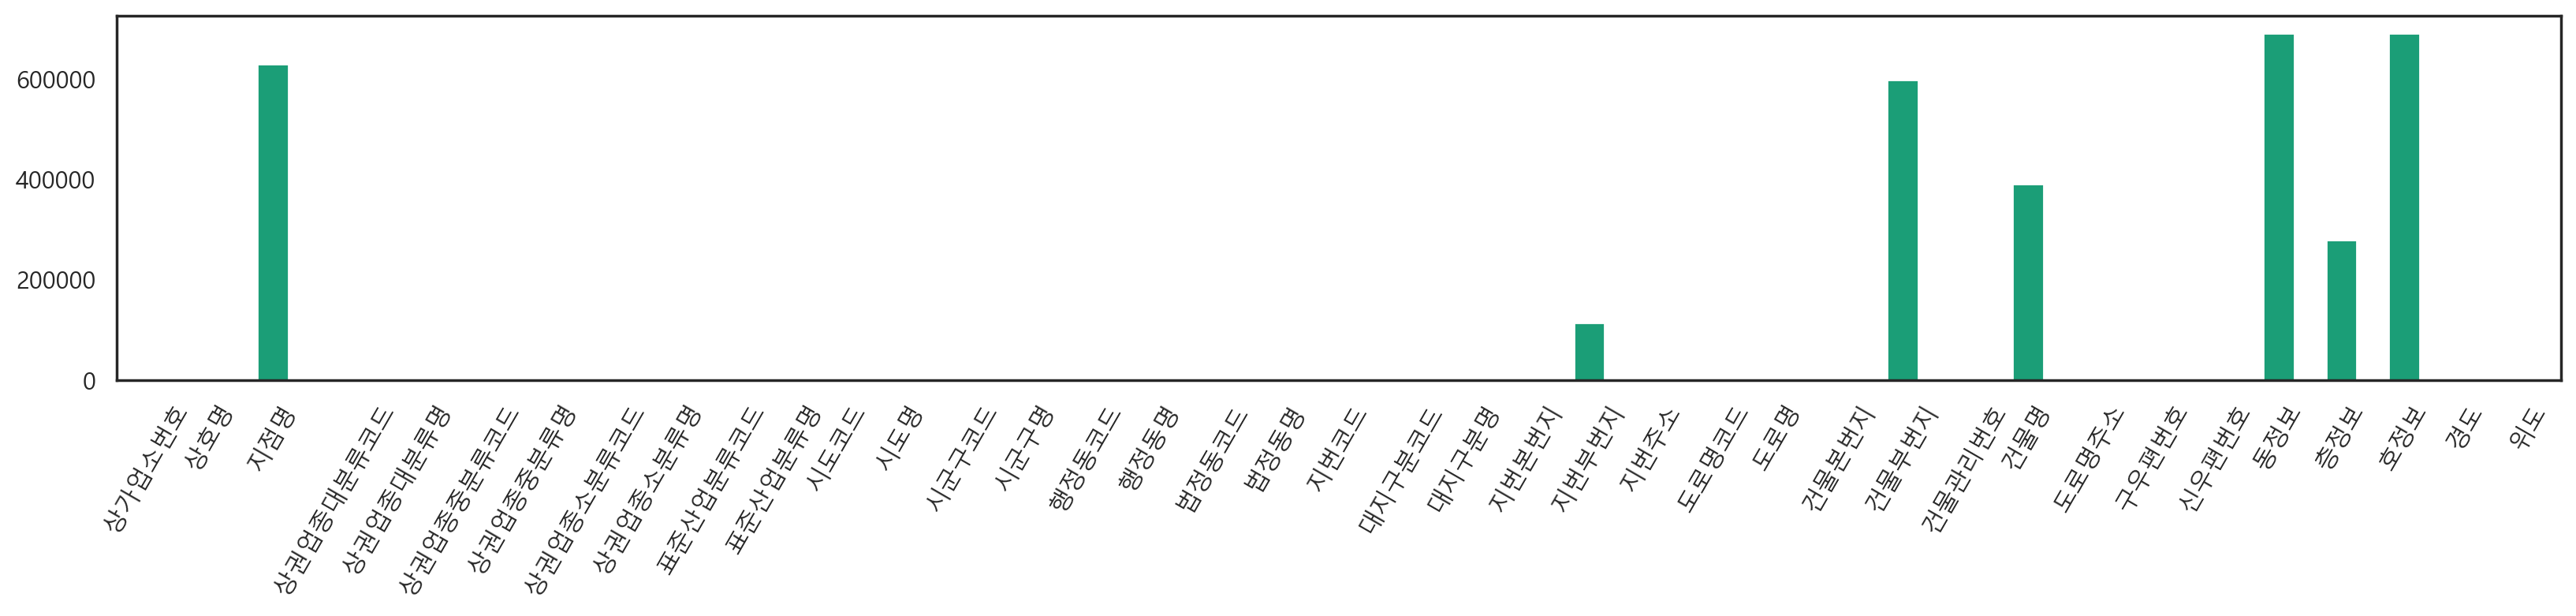

In [93]:
# missing_cnt.plot(kind='bar')
missing_cnt.plot(kind='bar', figsize=(20,3),rot=60)

In [96]:
missing_cnt_sorted=missing_cnt.sort_values(ascending=False)
missing_cnt_sorted.head(2)

호정보    692592
동정보    692592
dtype: int64

<Axes: >

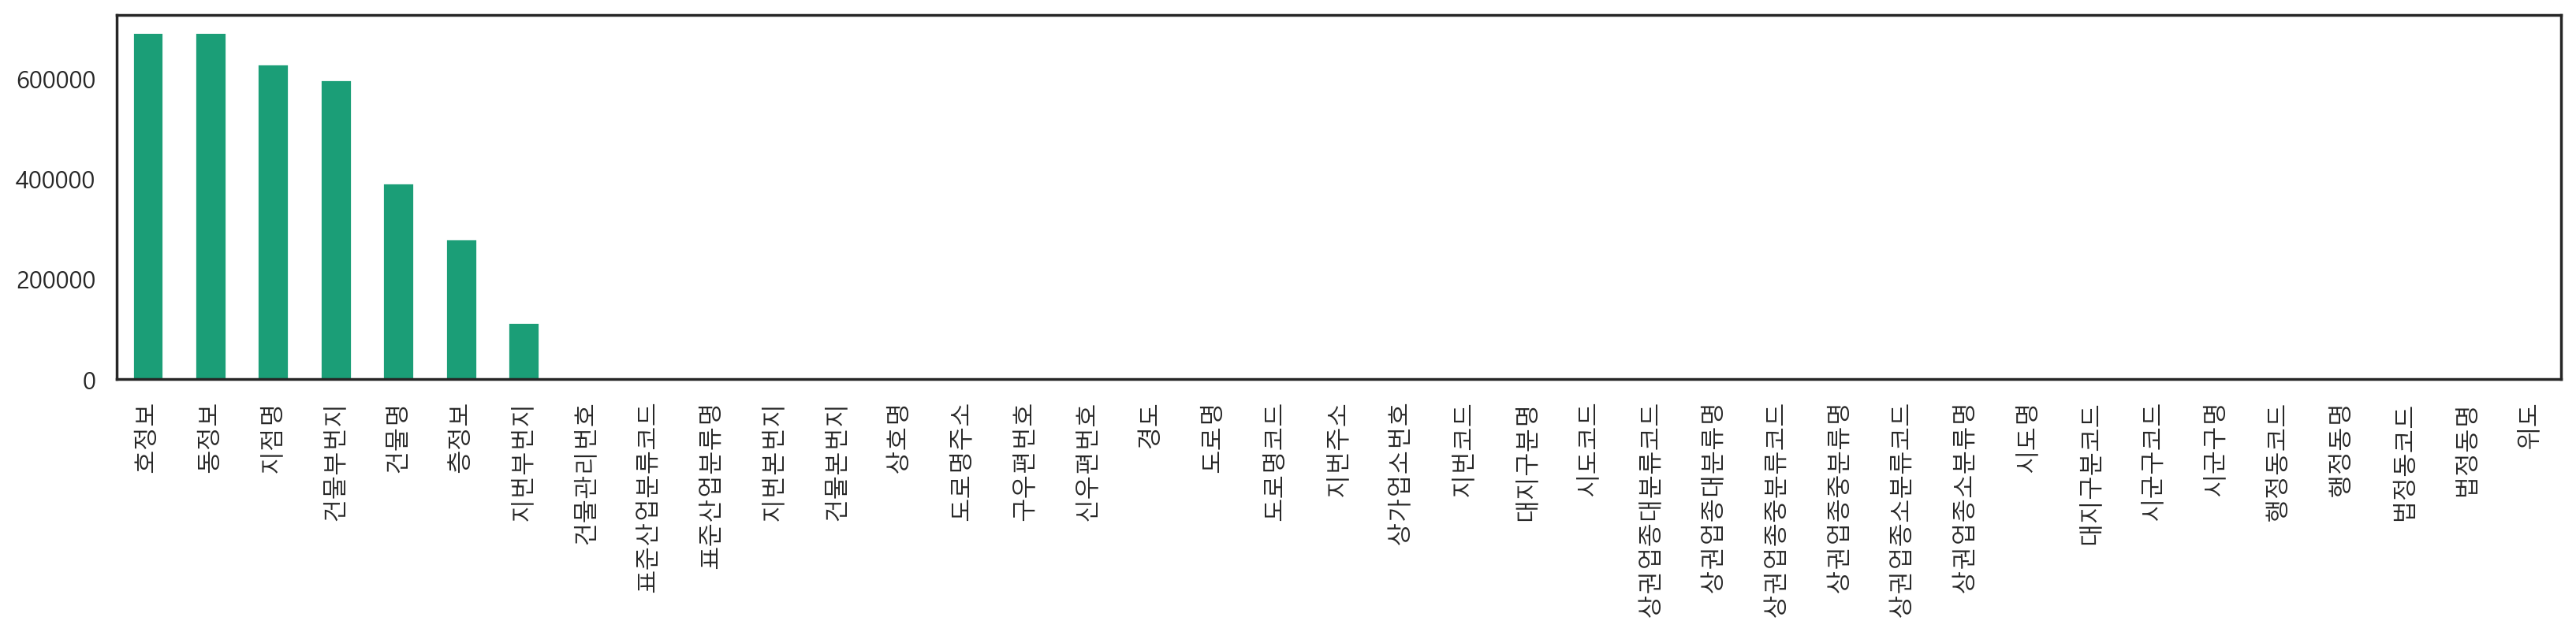

In [97]:
missing_cnt_sorted.plot(kind='bar',figsize=(20,3))

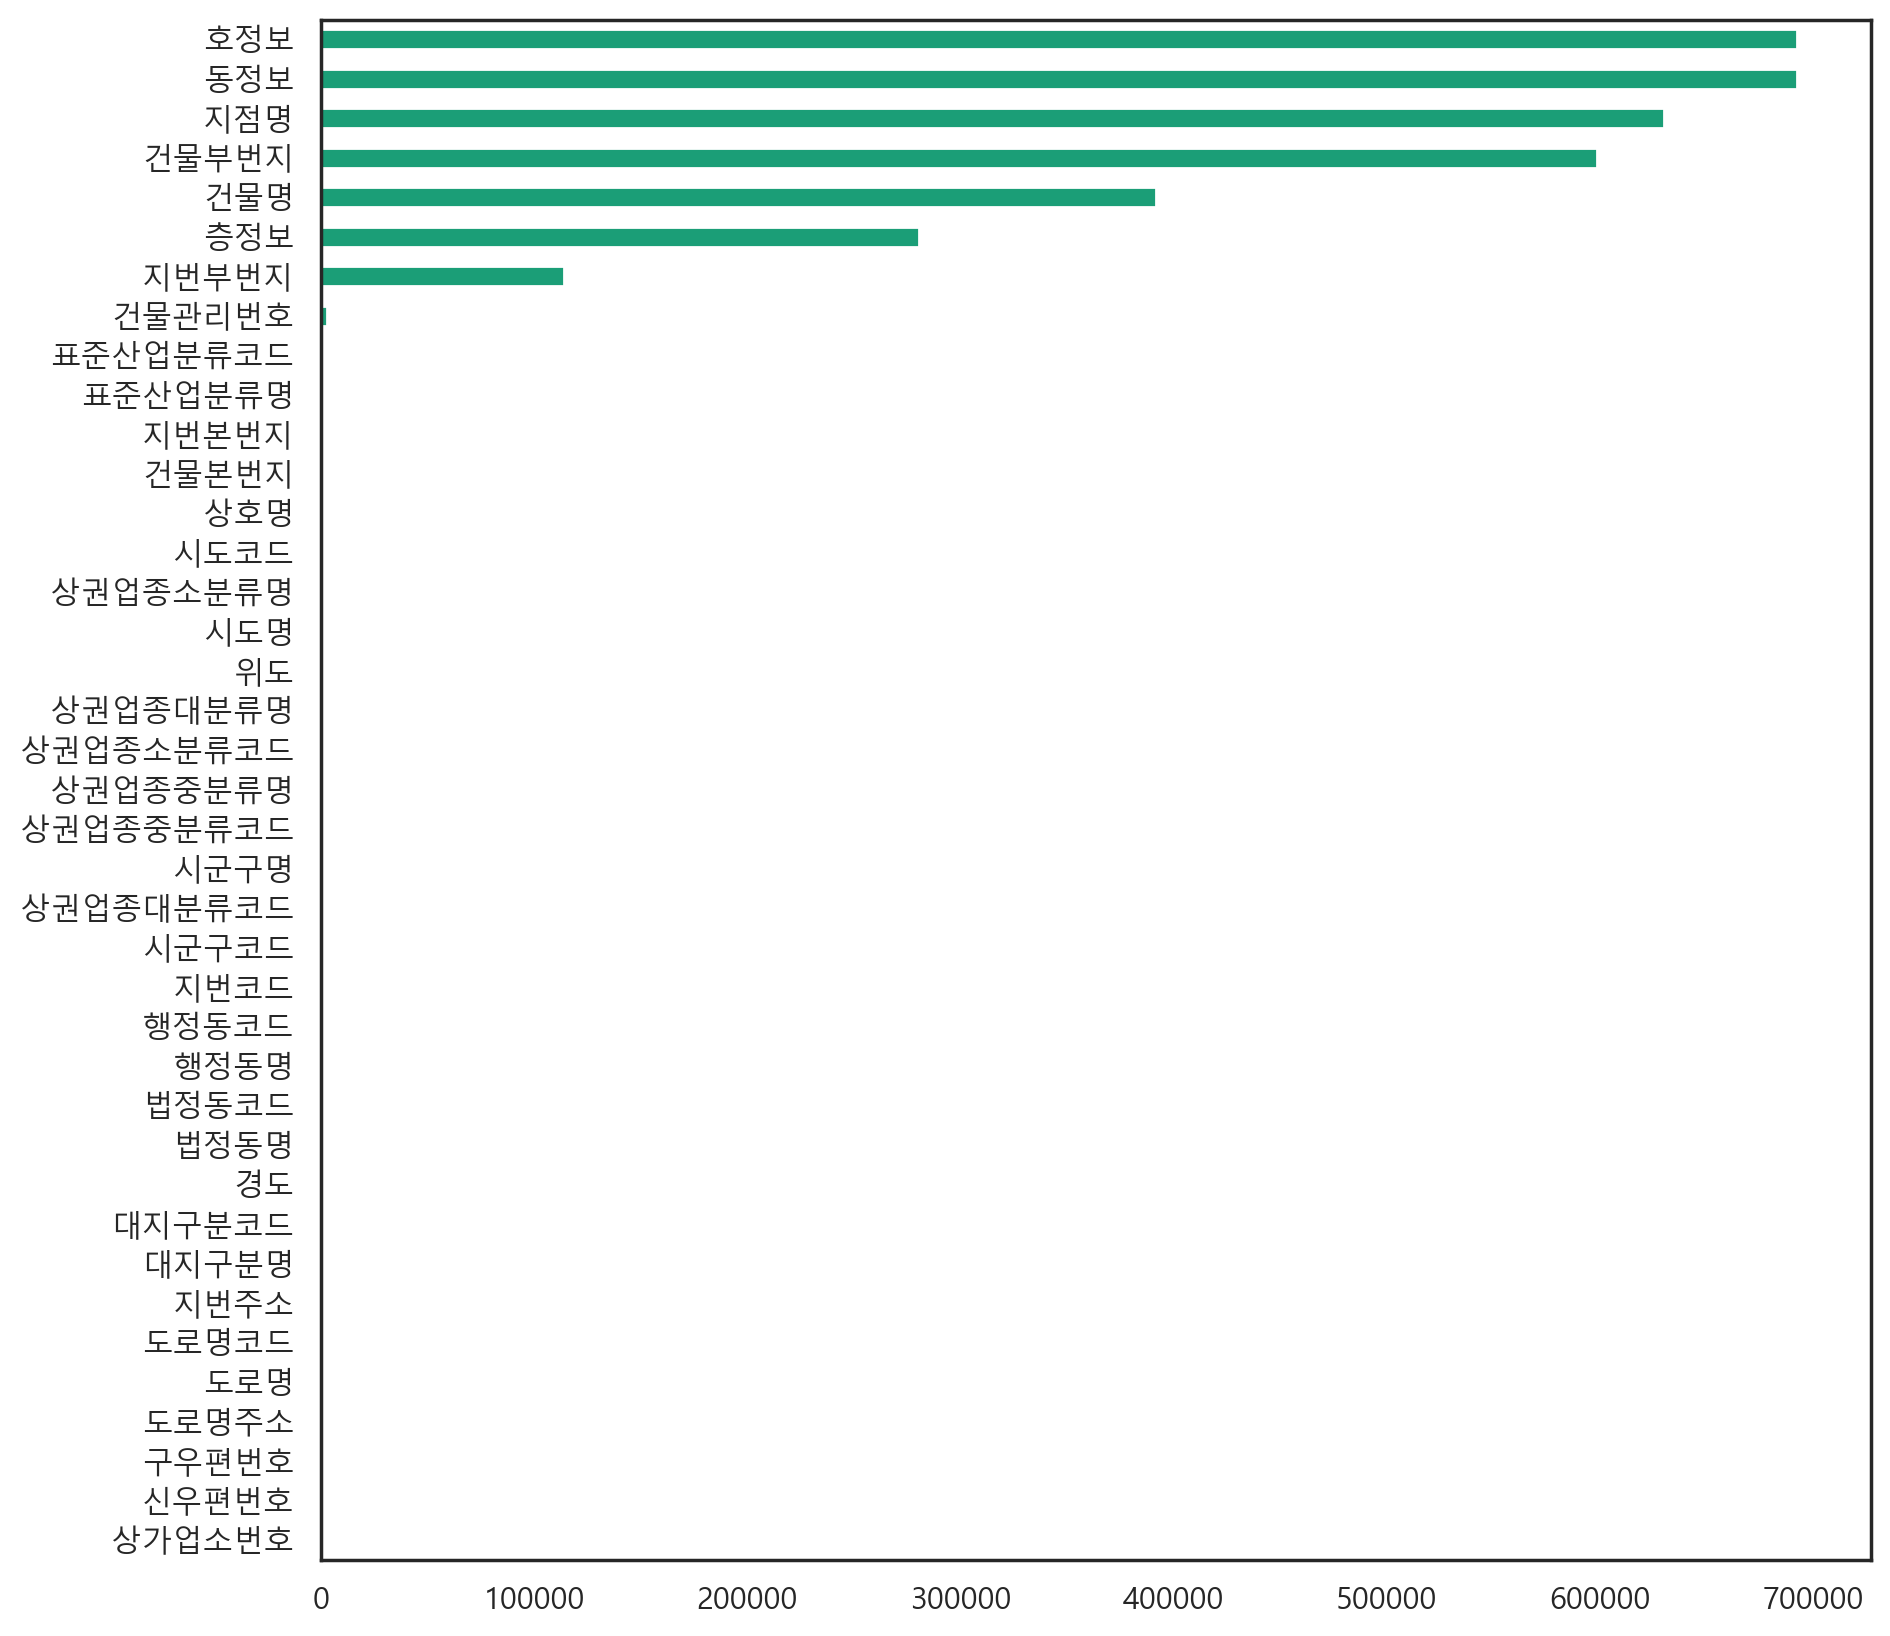

In [103]:
missing_cnt.sort_values().plot(kind='barh',figsize=(10,10))
plt.show()

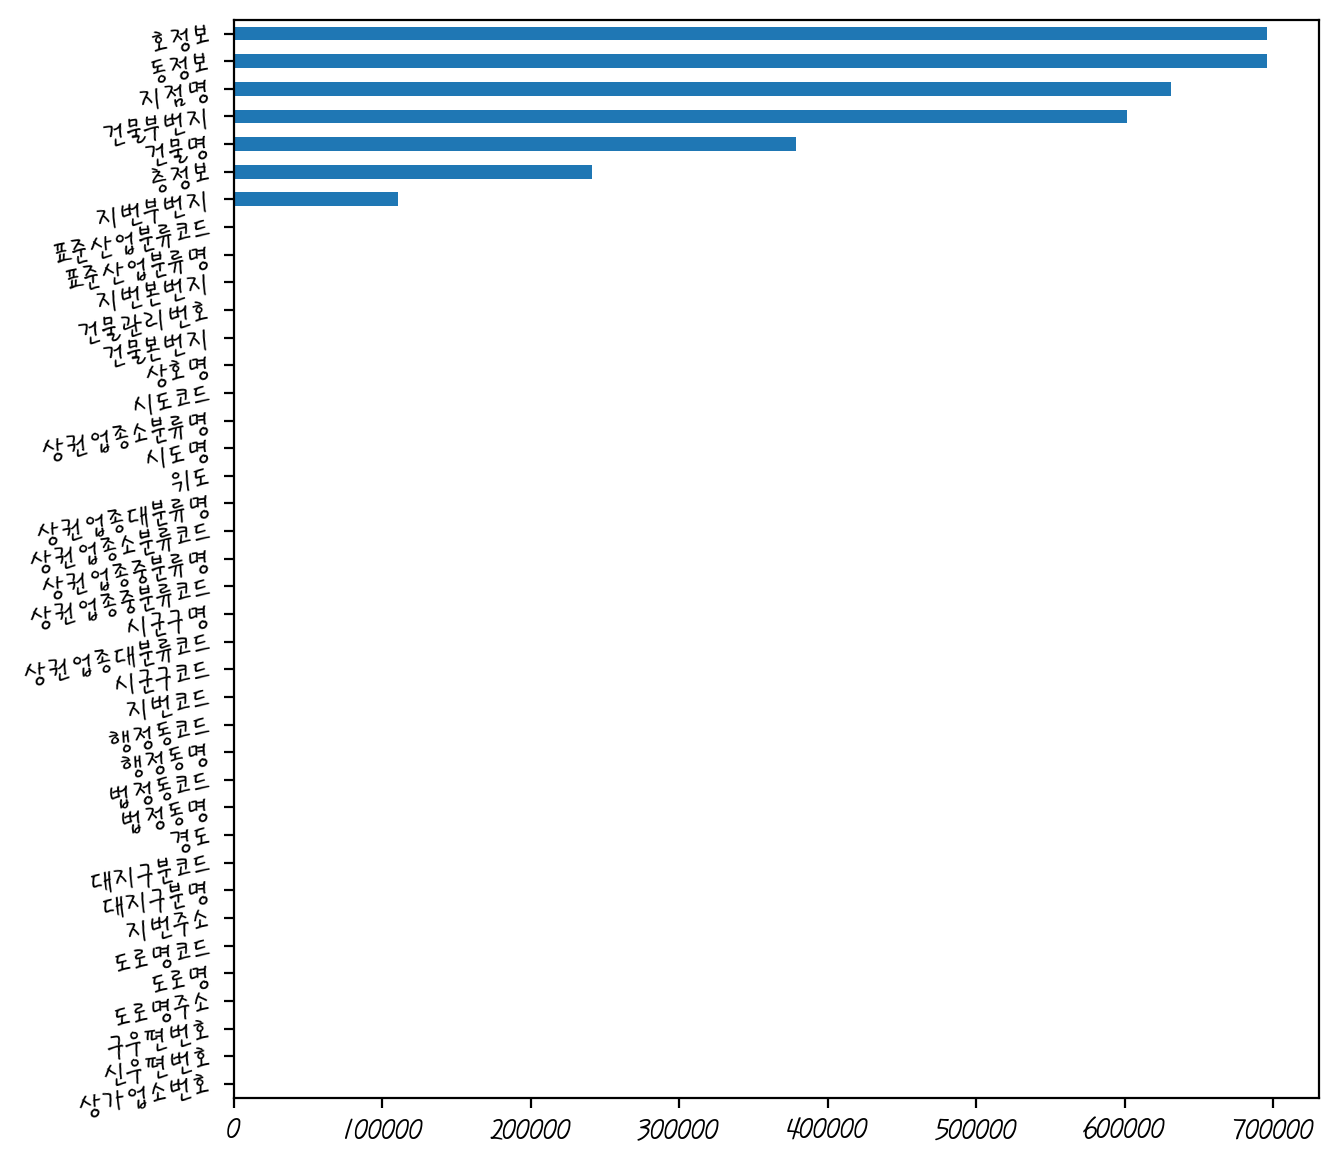

## ④ 결측치가 없는 컬럼는 제외하고 시각화(정렬전 bar plot, barh plot, 정렬 후 bar plot, barh plot).

In [113]:
#결측치가 있는 열만
only_missing_cnt = missing_cnt[missing_cnt!=0]
for i, (col,val) in enumerate(only_missing_cnt.items()):
    print(i, col,val)


0 상호명 1
1 지점명 630376
2 표준산업분류코드 211
3 표준산업분류명 211
4 지번본번지 29
5 지번부번지 113977
6 건물본번지 2
7 건물부번지 598859
8 건물관리번호 2912
9 건물명 391896
10 동정보 692592
11 층정보 280540
12 호정보 692592


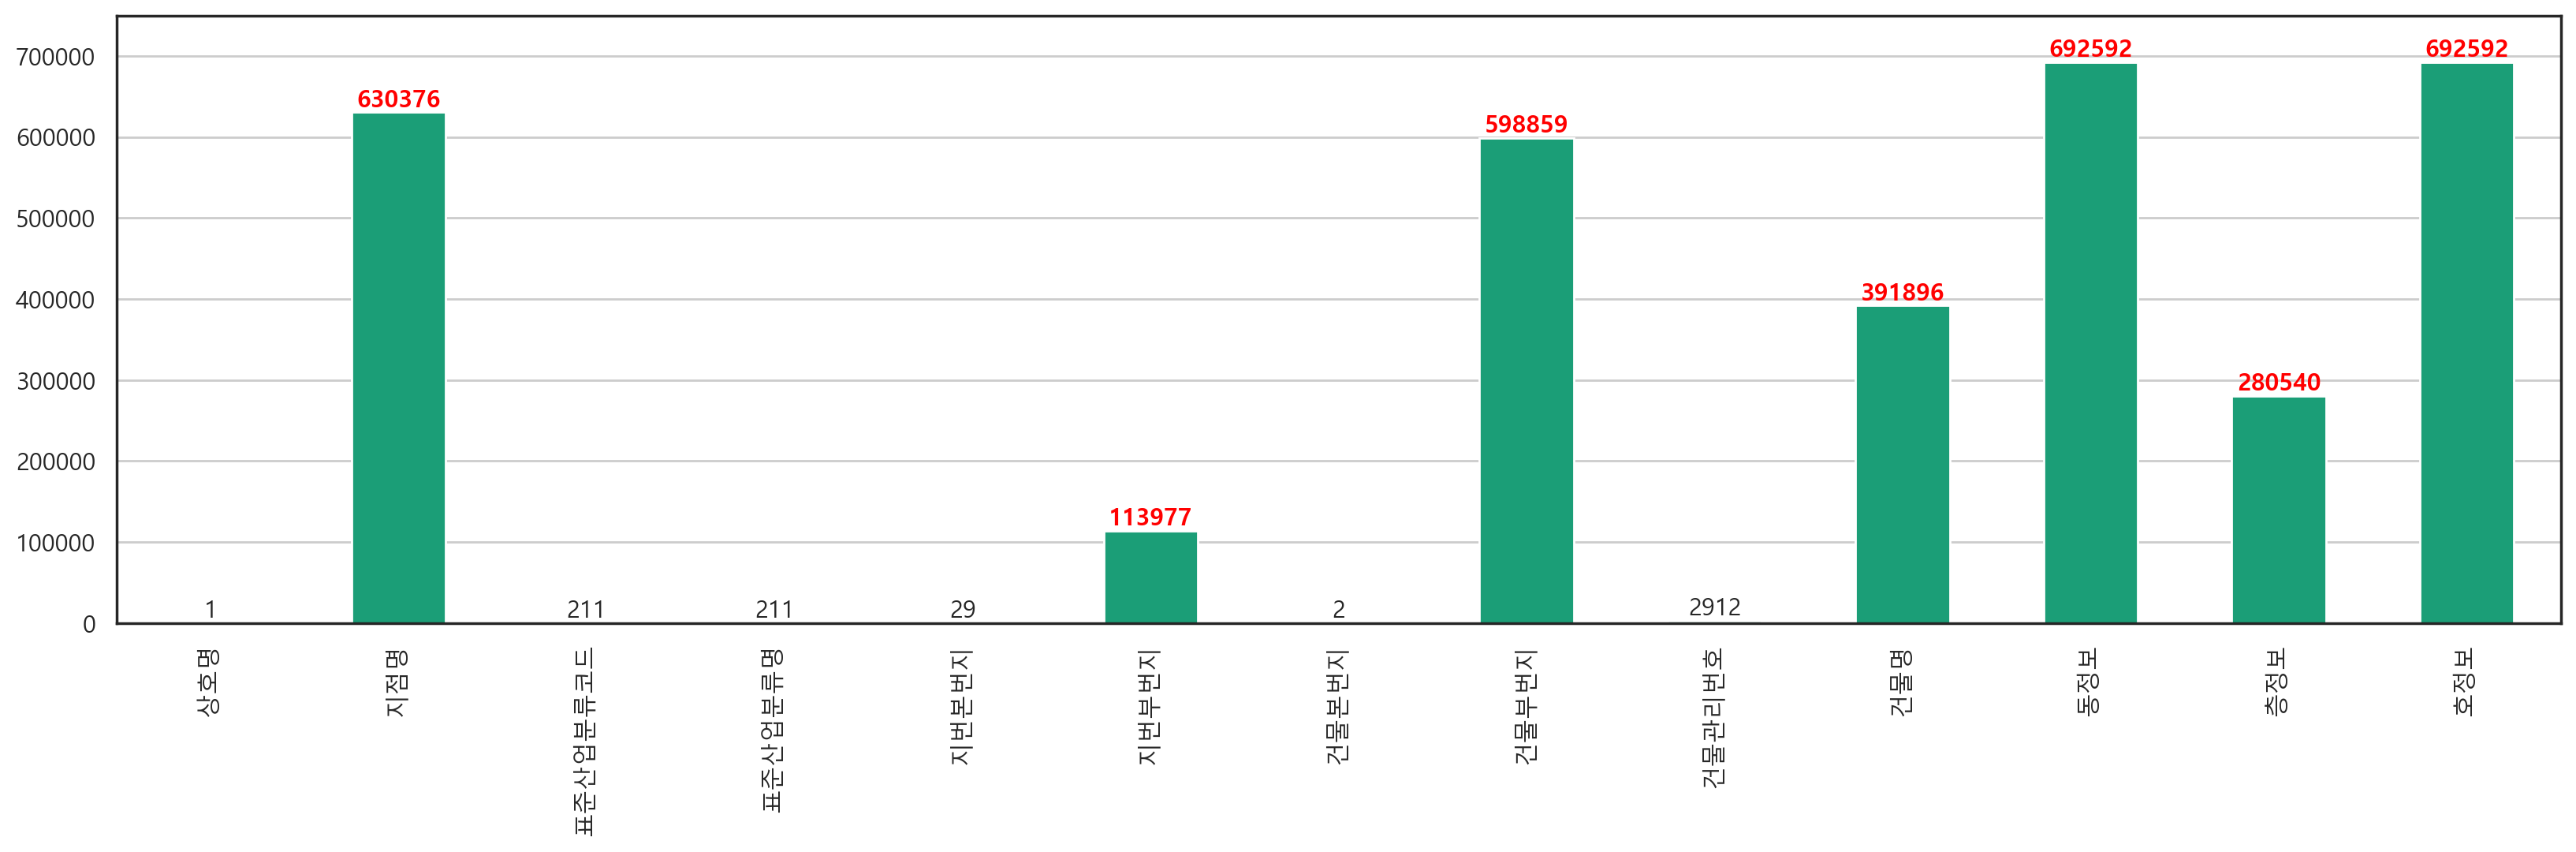

In [128]:
only_missing_cnt.plot(kind='bar',figsize=(20,5),ylim=[0,750000])
for i, val in enumerate(only_missing_cnt):
    if val > 100000:
        plt.text(i,val,round(val),va='bottom',ha='center',size=11, color='r',weight='bold')
    else:
        plt.text(i,val,round(val),va='bottom',ha='center',size=11)    
plt.grid(axis='y')

In [133]:
# data : only_missing_cnt.to_frame()
# x축 : index
# y축 : 0열
result =only_missing_cnt.to_frame()
result.columns = ['결측치수']
result.head(1)

,결측치수
상호명,1


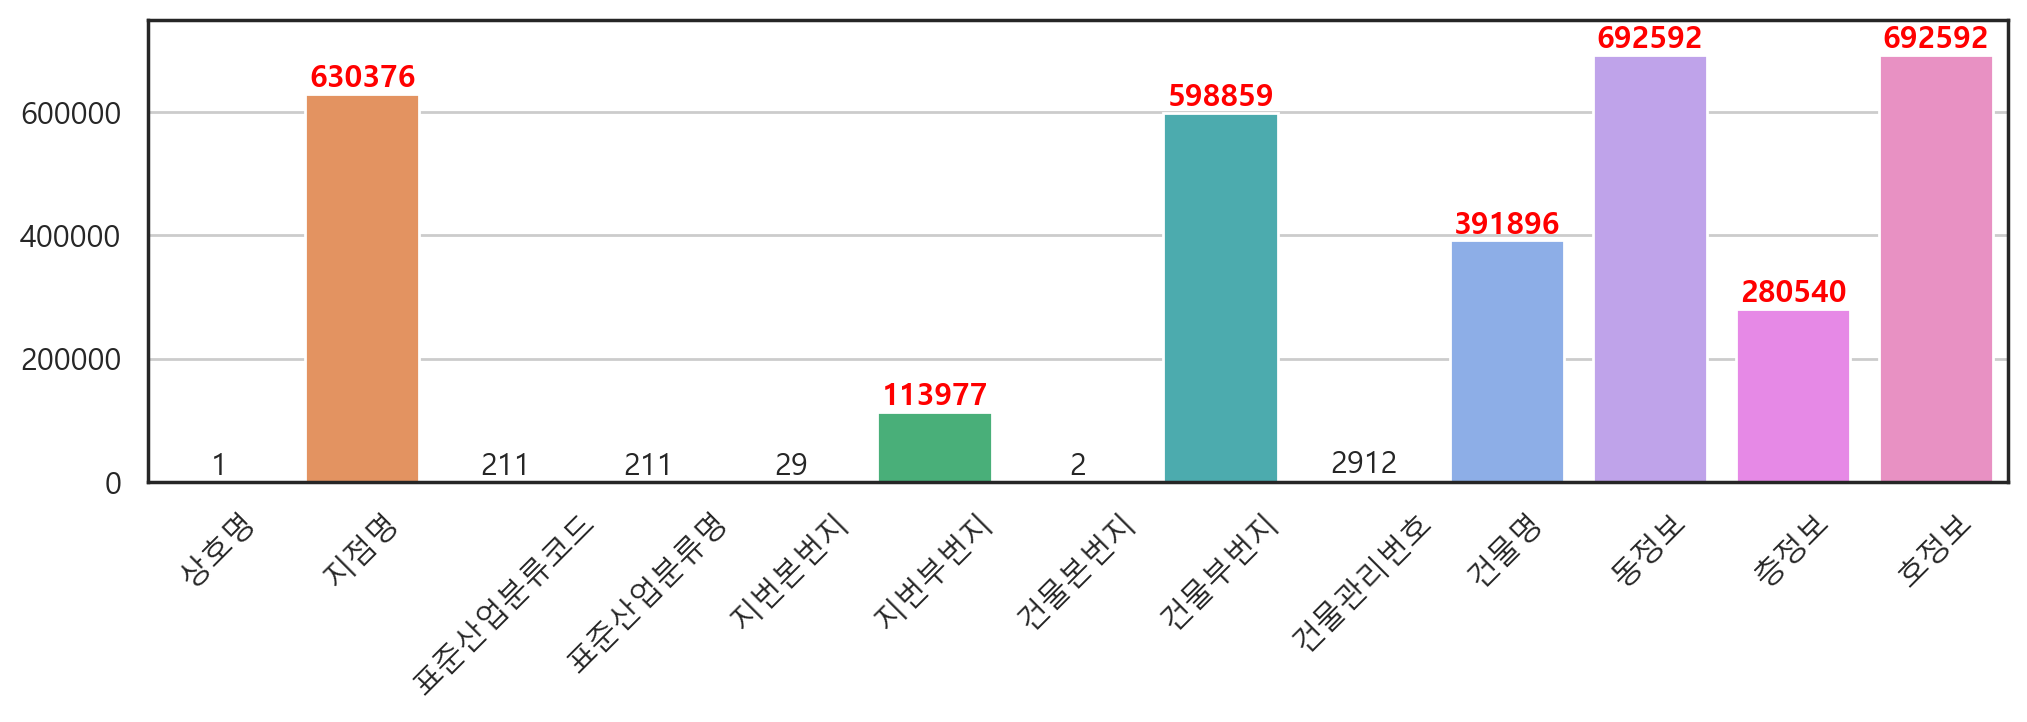

In [142]:
# sns.barplot(data=result,x=result.index,y='결측치수')
sns.barplot(x=only_missing_cnt.index,y=only_missing_cnt)

for i, val in enumerate(only_missing_cnt):
    if val > 100000:
        plt.text(i,val,round(val),va='bottom',ha='center',size=11, color='r',weight='bold')
    else:
        plt.text(i,val,round(val),va='bottom',ha='center',size=11) 
plt.ylim(0,750000)
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


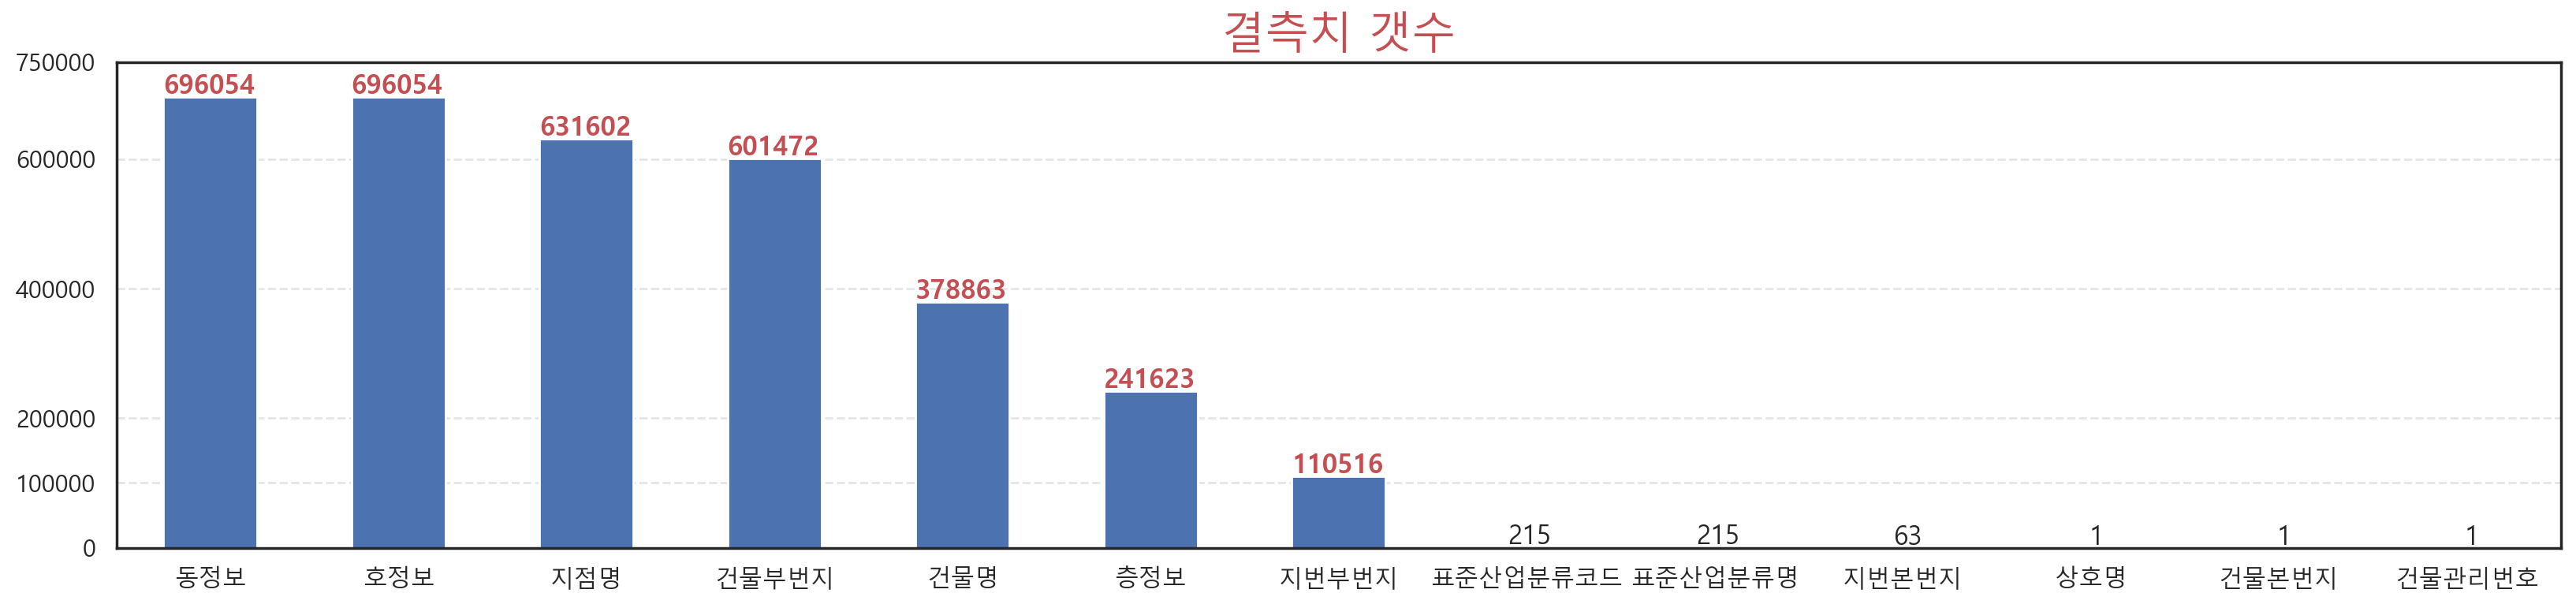

## ⑤ missingno 라이브러리로 결측치 시각화
* [ResidentMario/missingno: Missing data visualization module for Python](https://github.com/ResidentMario/missingno)

* 위의 사이트를 열어 사용법 확인
아나콘다 프롬프트에서 라이브러리 install`pip install missingno`

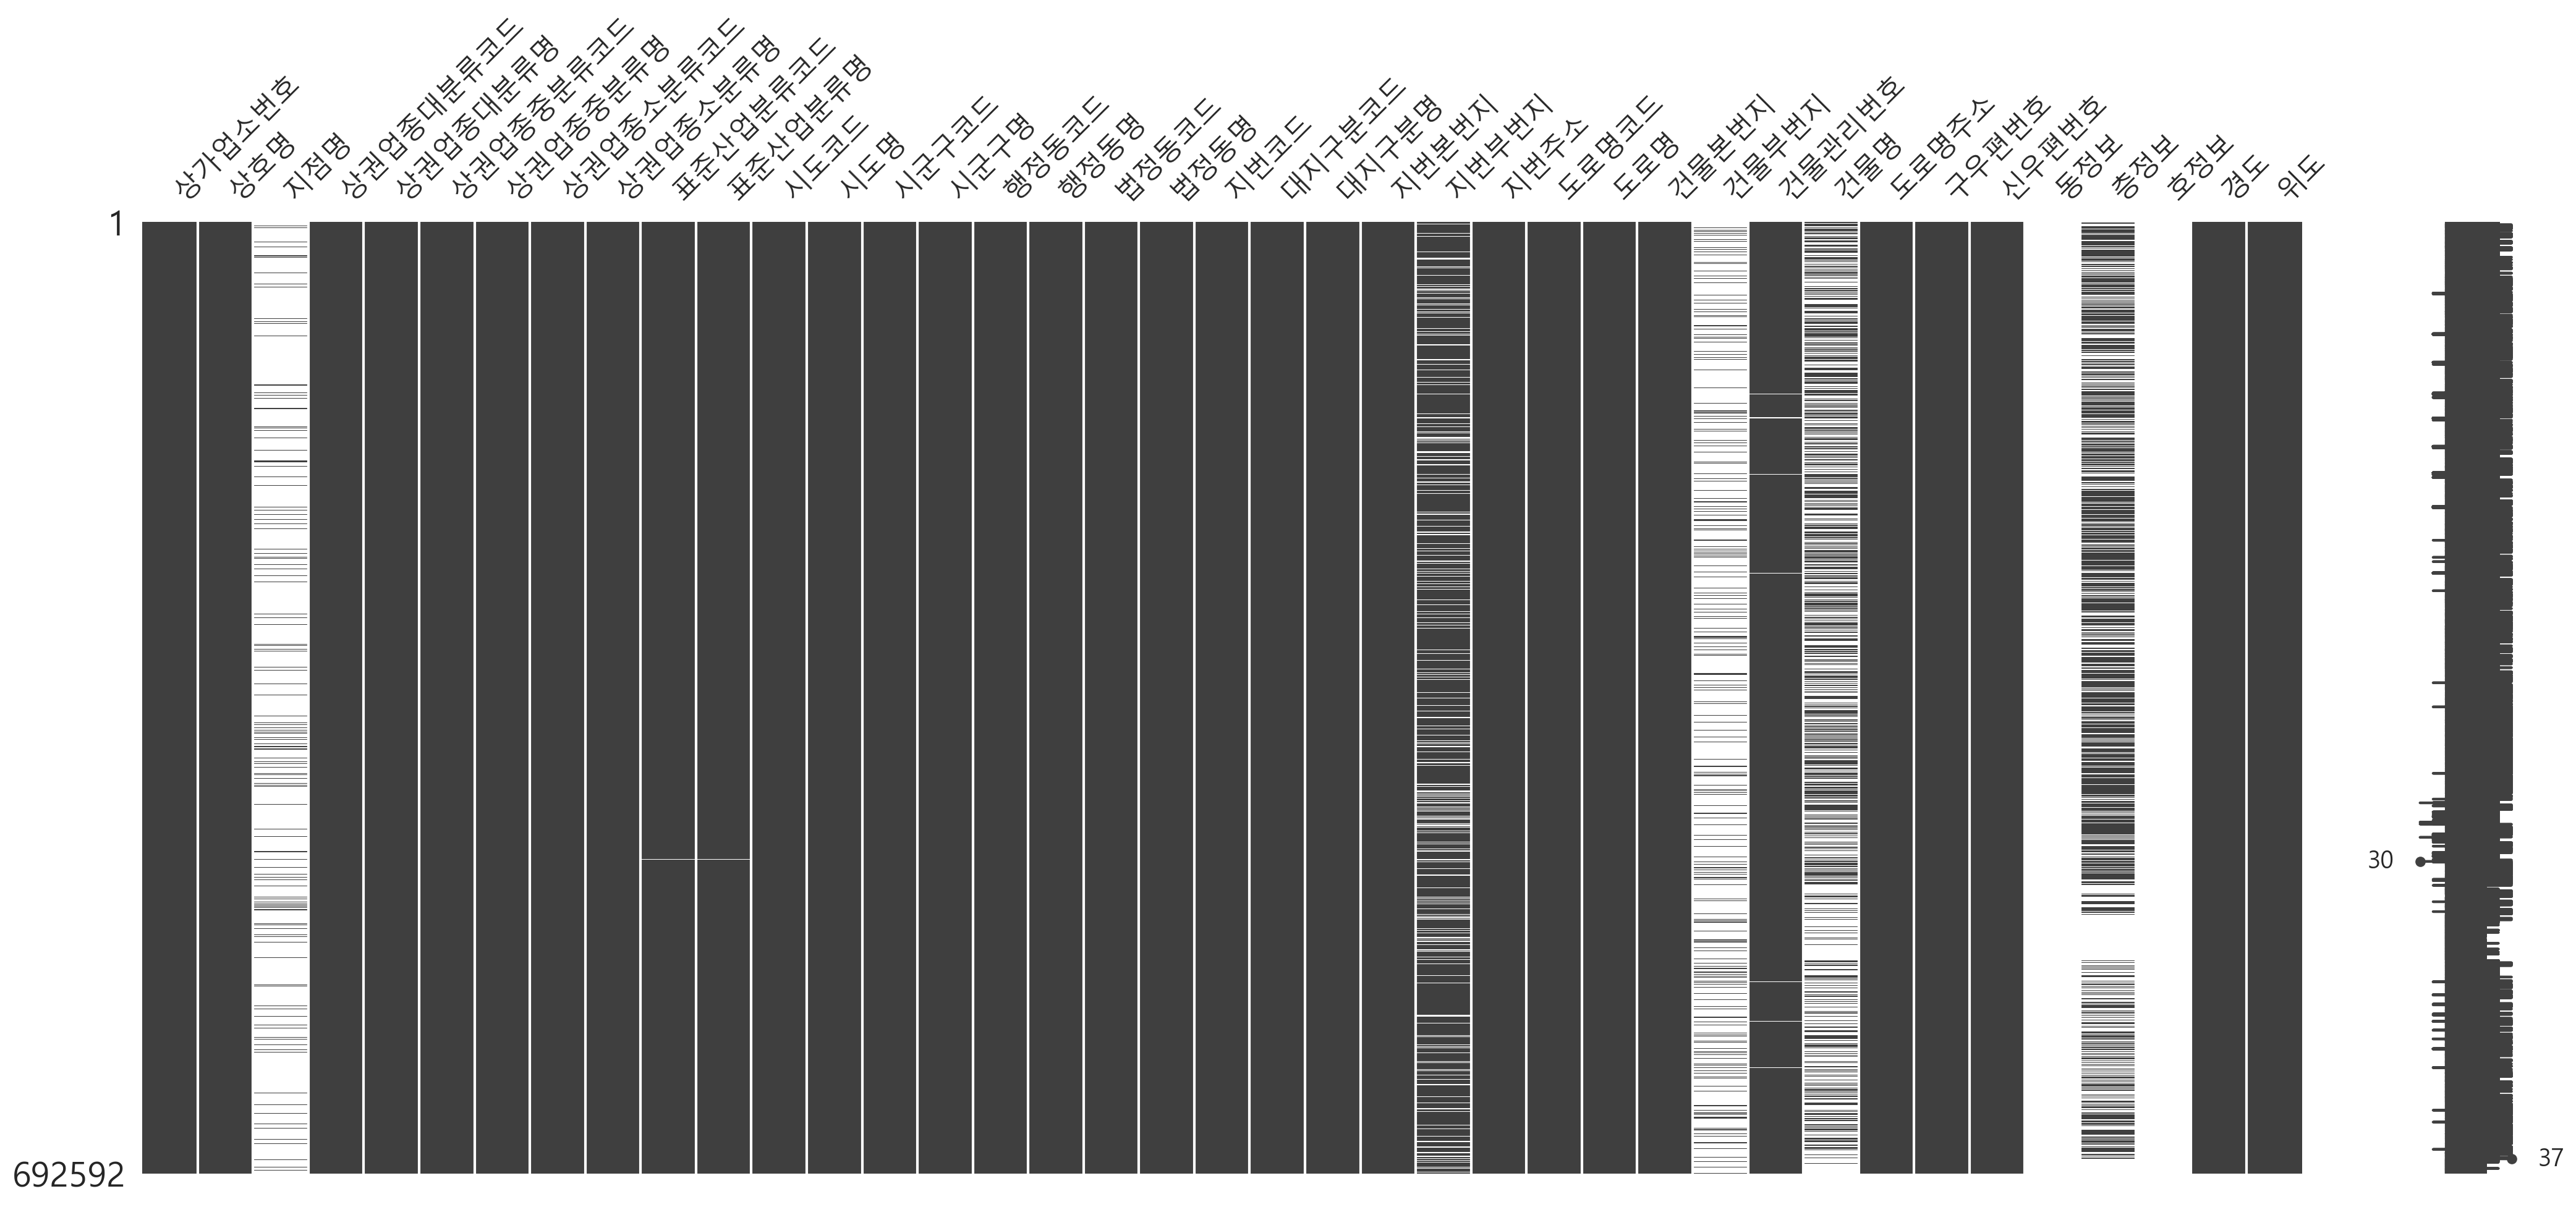

In [145]:
import missingno as msno
msno.matrix(df) # 결측치가 없는 부분은 검정색, 결측치 부분은 흰색
plt.show()

<Axes: >

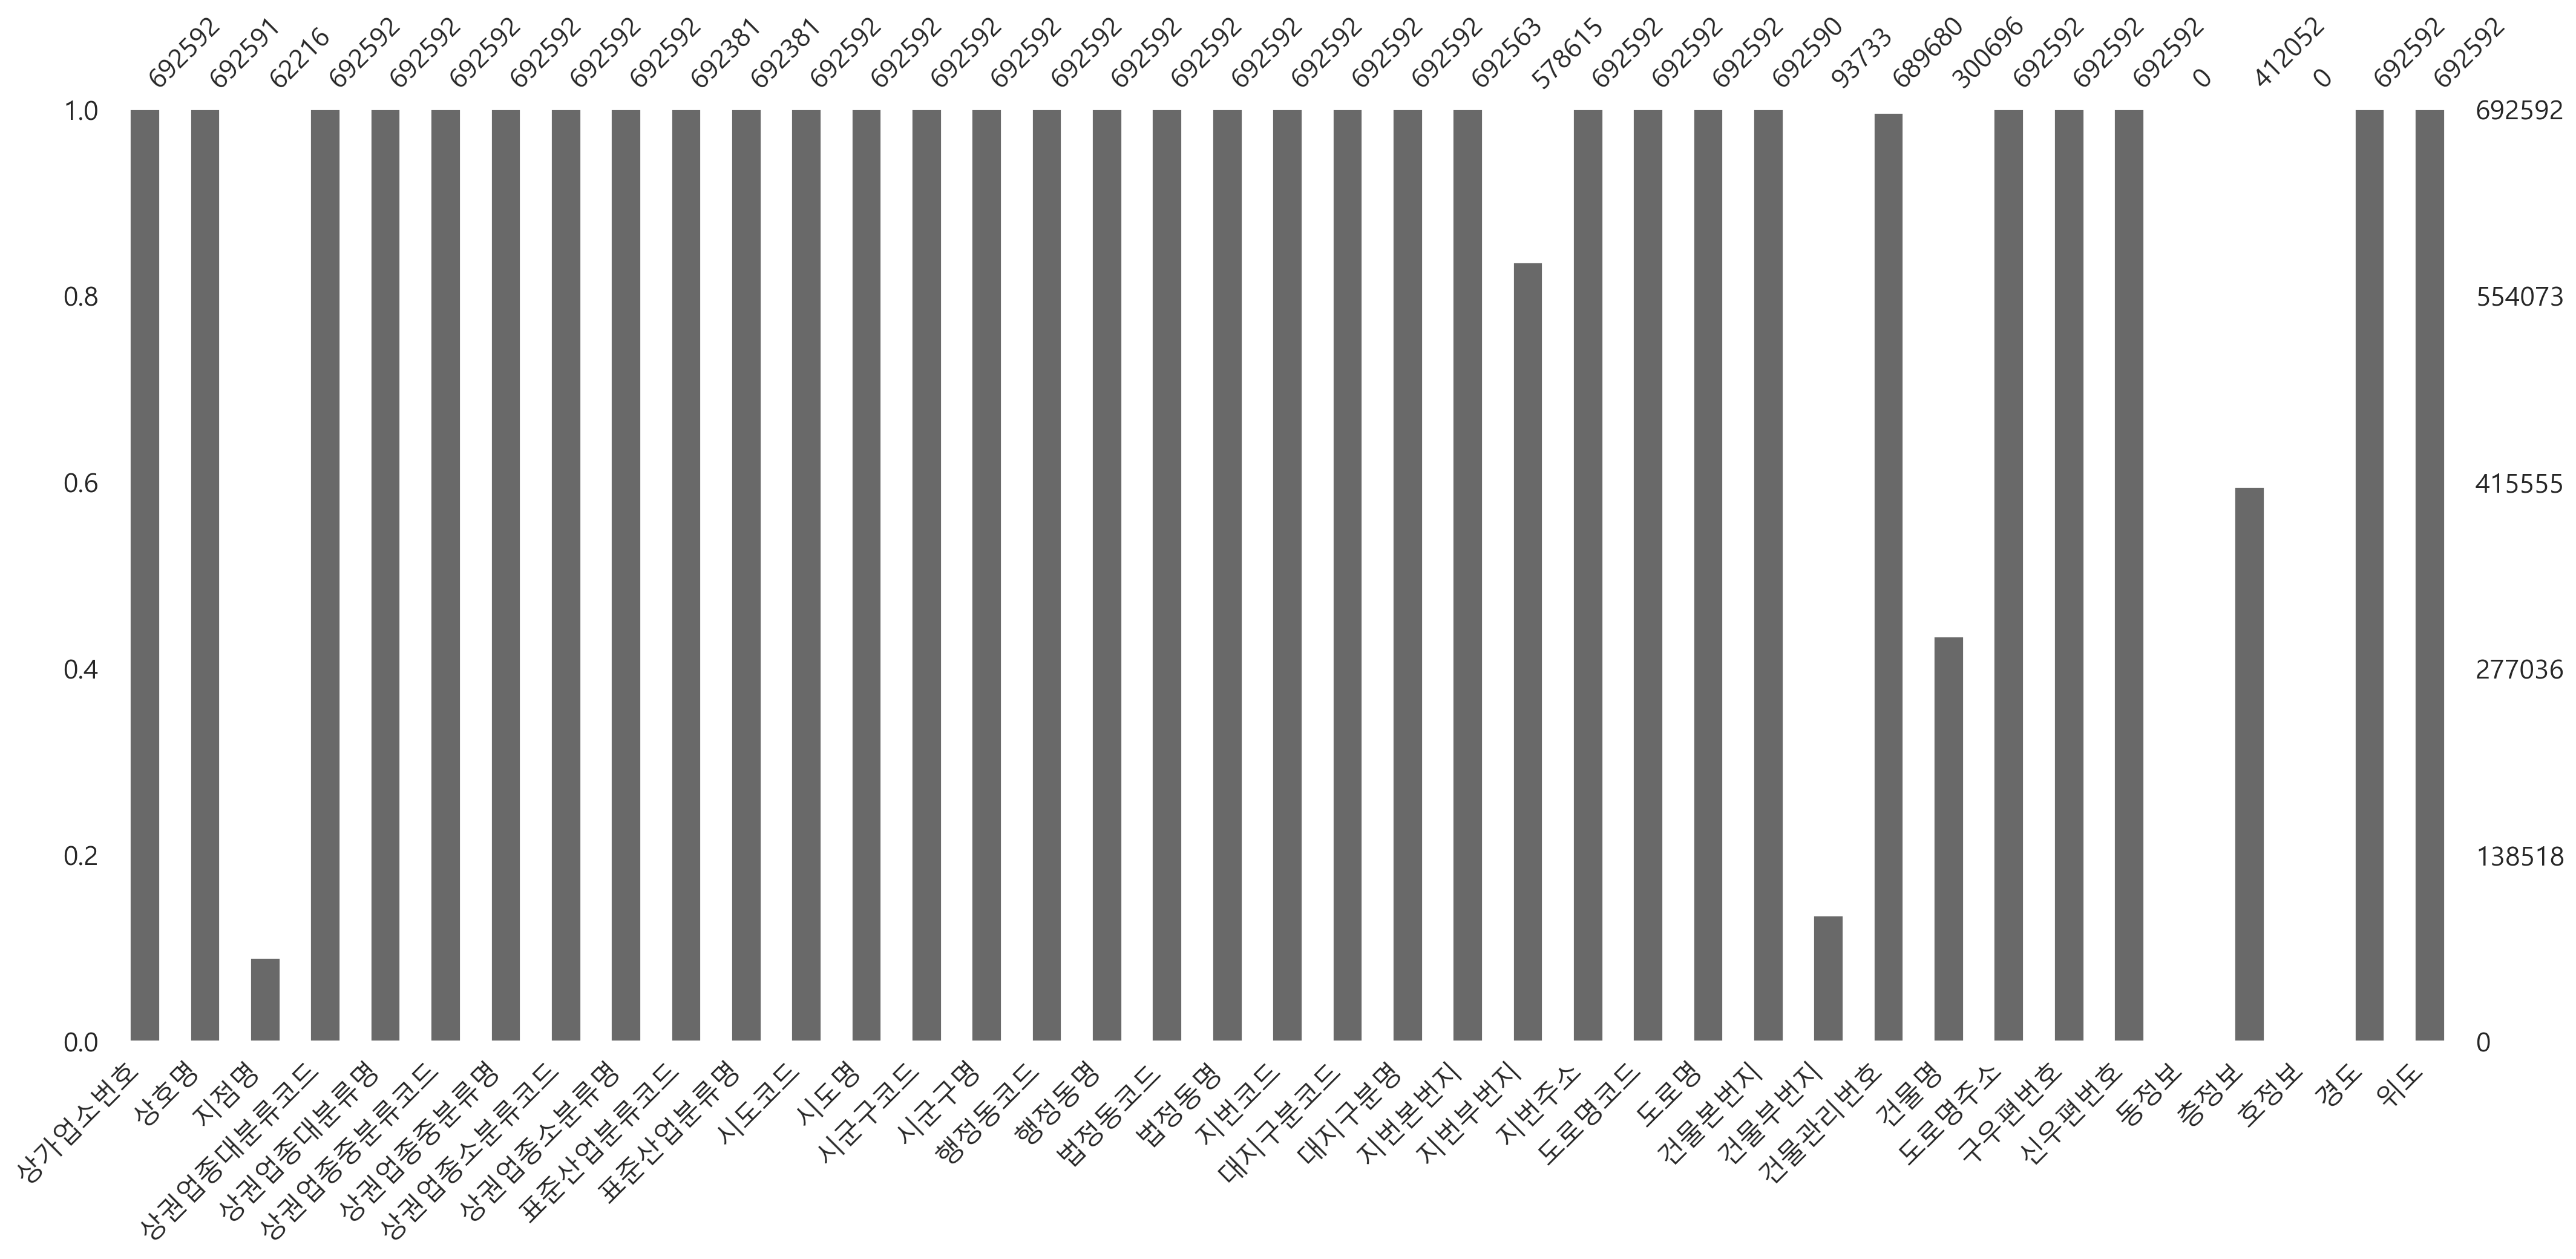

In [151]:
msno.bar(df) # 결측치가 아닌 데이터 갯수를 포함한 barplot

# 4.	df 데이터 셋에서 사용하지 않을 컬럼은 제거
## ①결측치가 너무 많은 컬럼은 제거한다. 결측치가 너무 많은 상위 8개 컬럼은 제거함.


In [155]:
#결측치가 많은 컬럼명
not_use=df.isnull().sum().sort_values(ascending=False).head(7)
not_use

호정보      692592
동정보      692592
지점명      630376
건물부번지    598859
건물명      391896
층정보      280540
지번부번지    113977
dtype: int64

In [159]:
[round(col/df.shape[0]*100,2) for col in not_use]

[100.0, 100.0, 91.02, 86.47, 56.58, 40.51, 16.46]

In [161]:
#결측치 비율
round(not_use/df.shape[0]*100,2)

호정보      100.00
동정보      100.00
지점명       91.02
건물부번지     86.47
건물명       56.58
층정보       40.51
지번부번지     16.46
dtype: float64

In [162]:
#삭제할 컬럼명
not_use.index

Index(['호정보', '동정보', '지점명', '건물부번지', '건물명', '층정보', '지번부번지'], dtype='object')

In [166]:
#컬럼 삭제전 206.1+ MB, 컬럼수 39개    삭제후 89.8+ MB, 컬럼수 17개
print('컬럼제거전 shape:',df.shape)
df=df.drop(not_use.index,axis=1)

컬럼제거전 shape: (692592, 39)


In [167]:
print('컬럼제거후 shape:',df.shape)

컬럼제거후 shape: (692592, 32)


In [ ]:
#cols에 코드나 번호가 포함되어 있는 컬럼명 추출


In [171]:
cols=df.columns
cols[(cols.str.find('코드')!=-1) | (cols.str.find('번호')!=-1)]

Index(['상가업소번호', '상권업종대분류코드', '상권업종중분류코드', '상권업종소분류코드', '표준산업분류코드', '시도코드',
       '시군구코드', '행정동코드', '법정동코드', '지번코드', '대지구분코드', '도로명코드', '건물관리번호', '구우편번호',
       '신우편번호'],
      dtype='object')

In [174]:
drop_cols=cols[cols.str.contains('코드|번호')]

In [175]:
df.drop(drop_cols,axis=1,inplace=True)
print('컬럼 코드번호 제거후 shape:',df.shape)

컬럼 코드번호 제거후 shape: (692592, 17)


In [176]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692592 entries, 0 to 692591
Data columns (total 17 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   상호명       692591 non-null  object 
 1   상권업종대분류명  692592 non-null  object 
 2   상권업종중분류명  692592 non-null  object 
 3   상권업종소분류명  692592 non-null  object 
 4   표준산업분류명   692381 non-null  object 
 5   시도명       692592 non-null  object 
 6   시군구명      692592 non-null  object 
 7   행정동명      692592 non-null  object 
 8   법정동명      692592 non-null  object 
 9   대지구분명     692592 non-null  object 
 10  지번본번지     692563 non-null  float64
 11  지번주소      692592 non-null  object 
 12  도로명       692592 non-null  object 
 13  건물본번지     692590 non-null  float64
 14  도로명주소     692592 non-null  object 
 15  경도        692592 non-null  float64
 16  위도        692592 non-null  float64
dtypes: float64(4), object(13)
memory usage: 89.8+ MB


In [179]:
df.to_csv('c:/ai/downloads/shareData/상가정보/서울부산상가정보백업.csv.zip',index=False,compression='infer')

## ②	컬럼명에 “코드”나 “번호”가 있는 컬럼은 분석에 사용되지 않을 예정입니다. 제거함

**※ 시리즈에 문자함수를 쓰기 위해 참조 :**
https://pandas.pydata.org/pandas-docs/stable/reference/series.html#string-handling

# ※ df 파일io

In [ ]:
#df.pd.read_csv('c:/ai/downloads/shareData/상가정보/서울부산상가정보백업.csv')

# 5. df 데이터 셋의 값을 가져온다(loc함수, iloc함수등을 사용하기도 하고 사용하지 않기도 하며 서브셋을 가져온다)
## ① 상호명 필드만 가져온다


In [180]:
df['상호명']
df.loc[:,'상호명']

0              참편한공인중개사사무소
1                  60계치킨암사
2                   성심인력공사
3                      칸토빈
4                  까치노래연습장
                ...       
692587        사회적협동조합 희망드림
692588                제주식품
692589                신천횟집
692590    주식회사  스타라이팅 일광지점
692591             이한나탁구클럽
Name: 상호명, Length: 692592, dtype: object

## ②상호명의 종류별 데이터수를 가져온다(df.상호명.value_counts()이용)

In [184]:
#상호명별 데이터 갯수
df.groupby('상호명')['경도'].count().sort_values(ascending=False).head()

상호명
업소명없음      793
컴퓨터수리      497
입시·교과학원    288
입주청소       262
김밥천국       214
Name: 경도, dtype: int64

In [185]:
df['상호명'].value_counts().head() # 위와 같은 결과 출력

업소명없음      793
컴퓨터수리      497
입시·교과학원    288
입주청소       262
김밥천국       214
Name: 상호명, dtype: int64

## ③	“상호명”과 "도로명주소” 컬럼 가져오기

In [188]:
df[['상호명','도로명주소']].head(1)

,상호명,도로명주소
0,참편한공인중개사사무소,서울특별시 서초구 방배로19길 25


## ④ 0~2행을 출력하라 (head()함수를 이용하지 않고, loc과 iloc을 이용)

In [190]:
df.loc[:2]
df.iloc[:3]
df[:3] # 조건,열이름, 행슬라이스 등이 데이터프레임변수[]안에 (열슬라이싱은 불가 하려면 loc)

,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,표준산업분류명,시도명,시군구명,행정동명,법정동명,대지구분명,지번본번지,지번주소,도로명,건물본번지,도로명주소,경도,위도
0,참편한공인중개사사무소,부동산,부동산 서비스,부동산 중개/대리업,부동산 중개 및 대리업,서울특별시,서초구,방배1동,방배동,대지,927.0,서울특별시 서초구 방배동 927-35,서울특별시 서초구 방배로19길,25.0,서울특별시 서초구 방배로19길 25,126.993691,37.484844
1,60계치킨암사,음식,기타 간이,치킨,치킨 전문점,서울특별시,강동구,암사2동,암사동,대지,502.0,서울특별시 강동구 암사동 502-4,서울특별시 강동구 상암로3길,8.0,서울특별시 강동구 상암로3길 8,127.126859,37.550810
2,성심인력공사,시설관리·임대,고용 알선,고용 알선업,고용 알선업,서울특별시,용산구,남영동,동자동,대지,43.0,서울특별시 용산구 동자동 43-59,서울특별시 용산구 한강대로,385.0,서울특별시 용산구 한강대로 385,126.972240,37.552803


'시설관리·임대'

# 6. 기술 통계값 보기 

- [Descriptive statistics - Wikipedia](https://en.wikipedia.org/wiki/Descriptive_statistics)
- [Computations / descriptive stats](https://pandas.pydata.org/docs/reference/frame.html#computations-descriptive-stats)
- [표준 편차 - 위키백과, 우리 모두의 백과사전](https://ko.wikipedia.org/wiki/표준편차)
* describe()를 사용하면 데이터 요약을 볼 수 있음(기술통계량)
    - 기본적으로 수치형 데이터를 요약
    - include, exclude 옵션으로 다른 데이터 타입의 요약 수치 출력
    - count, min, max, mean, median, 1사분위수, 3사분위수

### **개별 기술 통계값 구하기**

* [Computations / descriptive stats](https://pandas.pydata.org/docs/reference/frame.html#computations-descriptive-stats)
* count : 결측치를 제외한 값 갯수
* min, max: 최솟값, 최댓값
* argmin, argmax : 최솟값 인덱스, 최댓값 인덱스 반환
* quantile 특정 사분위수에 해당하는 값을 반환 (0~1 사이)
    * 0.25 : 1사분위 수
    * 0.5 : 2사분위수 (quantile 의 기본 값)
    * 0.75 : 3사분위수
* sum 수치 데이터의 합계
* mean 평균
* median 중앙값(중간값:데이터를 한 줄로 세웠을 때 가운데 위치하는 값, 중앙값이 짝수일 때는 가운데 2개 값의 평균을 구함)

* std, var 표준편차, 분산을 계산
* cumsum 맨 첫 번째 성분부터 각 성분까지의 누적합을 계산 (0 번째 부터 계속 더해짐)
* cumprod 맨 첫번째 성분부터 각 성분까지의 누적곱을 계산 (1 번째 부터 계속 곱해짐)
* cov, corr() : 공분산, 상관계수
* skew 왜도 (오른쪽으로 치우침= 왜도<0, 왼쪽으로 치우침=왜도>0)
* kurt 첨도


## ①	df 데이터셋의 요약기술 통계량

In [209]:
df.describe(include='object') #수치형에 대한 기술통계량    object형에 대한 기술통계량

,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,표준산업분류명,시도명,시군구명,행정동명,법정동명,대지구분명,지번주소,도로명,도로명주소
count,692591,692592,692592,692592,692381,692592,692592,692592,692592,692592,692592,692592,692592
unique,535061,10,75,247,386,2,39,630,647,2,221186,18817,220936
top,업소명없음,음식,한식,백반/한정식,한식 일반 음식점업,서울특별시,강남구,역삼1동,서초동,대지,서울특별시 송파구 문정동 634,서울특별시 강남구 테헤란로,서울특별시 송파구 충민로 66
freq,793,190725,75607,39765,60780,537489,64239,13420,17901,691744,881,4248,1123


In [205]:
df.dtypes

상호명          object
상권업종대분류명     object
상권업종중분류명     object
상권업종소분류명     object
표준산업분류명      object
시도명          object
시군구명         object
행정동명         object
법정동명         object
대지구분명        object
지번본번지       float64
지번주소         object
도로명          object
건물본번지       float64
도로명주소        object
경도          float64
위도          float64
dtype: object

## ②	df 데이터셋의 “지번본번지", "건물본번지” 컬럼의 데이터 개수와  dtype 메모리 사용량을 확인한다.

In [212]:
df[['지번본번지','건물본번지']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692592 entries, 0 to 692591
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   지번본번지   692563 non-null  float64
 1   건물본번지   692590 non-null  float64
dtypes: float64(2)
memory usage: 10.6 MB


In [215]:
df

,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,표준산업분류명,시도명,시군구명,행정동명,법정동명,대지구분명,지번본번지,지번주소,도로명,건물본번지,도로명주소,경도,위도
0,참편한공인중개사사무소,부동산,부동산 서비스,부동산 중개/대리업,부동산 중개 및 대리업,서울특별시,서초구,방배1동,방배동,대지,927.0,서울특별시 서초구 방배동 927-35,서울특별시 서초구 방배로19길,25.0,서울특별시 서초구 방배로19길 25,126.993691,37.484844
1,60계치킨암사,음식,기타 간이,치킨,치킨 전문점,서울특별시,강동구,암사2동,암사동,대지,502.0,서울특별시 강동구 암사동 502-4,서울특별시 강동구 상암로3길,8.0,서울특별시 강동구 상암로3길 8,127.126859,37.550810
2,성심인력공사,시설관리·임대,고용 알선,고용 알선업,고용 알선업,서울특별시,용산구,남영동,동자동,대지,43.0,서울특별시 용산구 동자동 43-59,서울특별시 용산구 한강대로,385.0,서울특별시 용산구 한강대로 385,126.972240,37.552803
3,칸토빈,음식,비알코올,카페,커피 전문점,서울특별시,강서구,공항동,공항동,산,20.0,서울특별시 강서구 공항동 산 20-2,서울특별시 강서구 방화동로,30.0,서울특별시 강서구 방화동로 30,126.810493,37.563548
4,까치노래연습장,예술·스포츠,유원지·오락,노래방,노래 연습장 운영업,서울특별시,노원구,상계5동,상계동,대지,169.0,서울특별시 노원구 상계동 169-179,서울특별시 노원구 한글비석로23길,2.0,서울특별시 노원구 한글비석로23길 2,127.071218,37.660715
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
692587,사회적협동조합 희망드림,과학·기술,기타 전문 과학,번역/통역 서비스업,번역 및 통역 서비스업,부산광역시,동구,범일2동,범일동,대지,830.0,부산광역시 동구 범일동 830-140,부산광역시 동구 조방로,14.0,부산광역시 동구 조방로 14,129.063451,35.138726
692588,제주식품,소매,종합 소매,슈퍼마켓,기타 음ㆍ식료품 위주 종합 소매업,부산광역시,남구,용호2동,용호동,대지,516.0,부산광역시 남구 용호동 516-10,부산광역시 남구 동명로152번길,93.0,부산광역시 남구 동명로152번길 93,129.112773,35.114914
692589,신천횟집,음식,한식,횟집,한식 일반 음식점업,부산광역시,중구,남포동,남포동4가,대지,37.0,부산광역시 중구 남포동4가 37-1,부산광역시 중구 자갈치해안로,52.0,부산광역시 중구 자갈치해안로 52,129.030569,35.096629
692590,주식회사 스타라이팅 일광지점,음식,비알코올,카페,커피 전문점,부산광역시,기장군,일광읍,일광읍,대지,4.0,부산광역시 기장군 일광읍 문동리 4,부산광역시 기장군 일광읍 일광로,808.0,부산광역시 기장군 일광읍 일광로 808,129.261431,35.312819


## ③	“위도", "경도” 컬럼만의 요약 기술통계량

In [214]:
df[['위도','경도']].describe()
#오른쪽 꼬리가 긴 분포(데이터가 왼쪽으로 치우침) : 중위수 <평균 - 왜도(skew) >0
#왼쪽 꼬리가 긴 분포(데이터가 오른쪽으로 치우침) : 중위수 >평균 - 왜도(skew) <0

,위도,경도
count,692592.000000,692592.000000
mean,37.008934,127.457120
std,0.991261,0.867369
min,34.989747,126.767661
25%,37.474629,126.943926
50%,37.514822,127.034613
75%,37.560404,127.131254
max,37.692604,129.294072


# 7.단별량 수치형 변수 시각화
## ① 위도의 빈도표를 시각화 : plot.hist, hist, sns.displot, sns.histplot

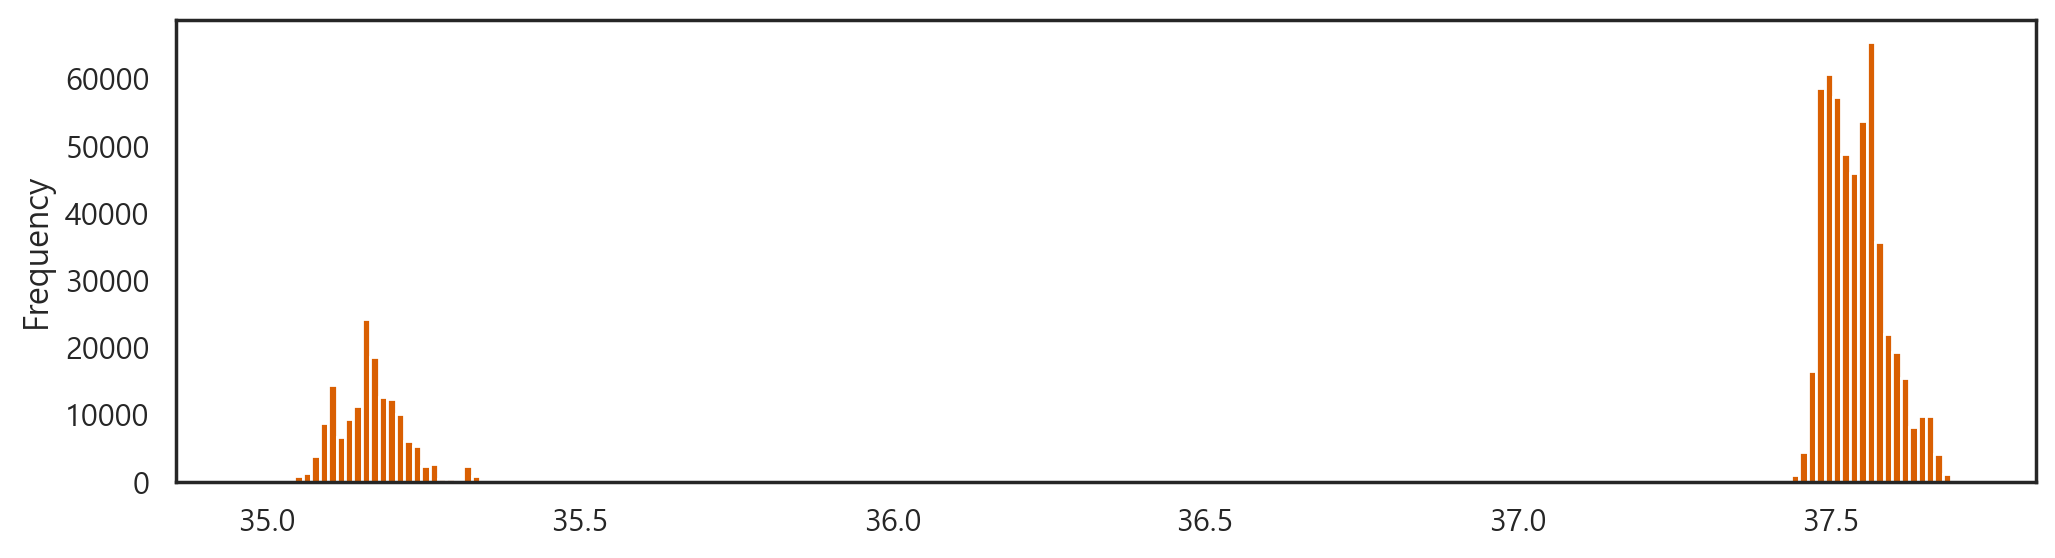

In [224]:
df['위도'].plot(kind='hist',bins=200)
df['위도'].plot.hist(bins=200)
plt.show()

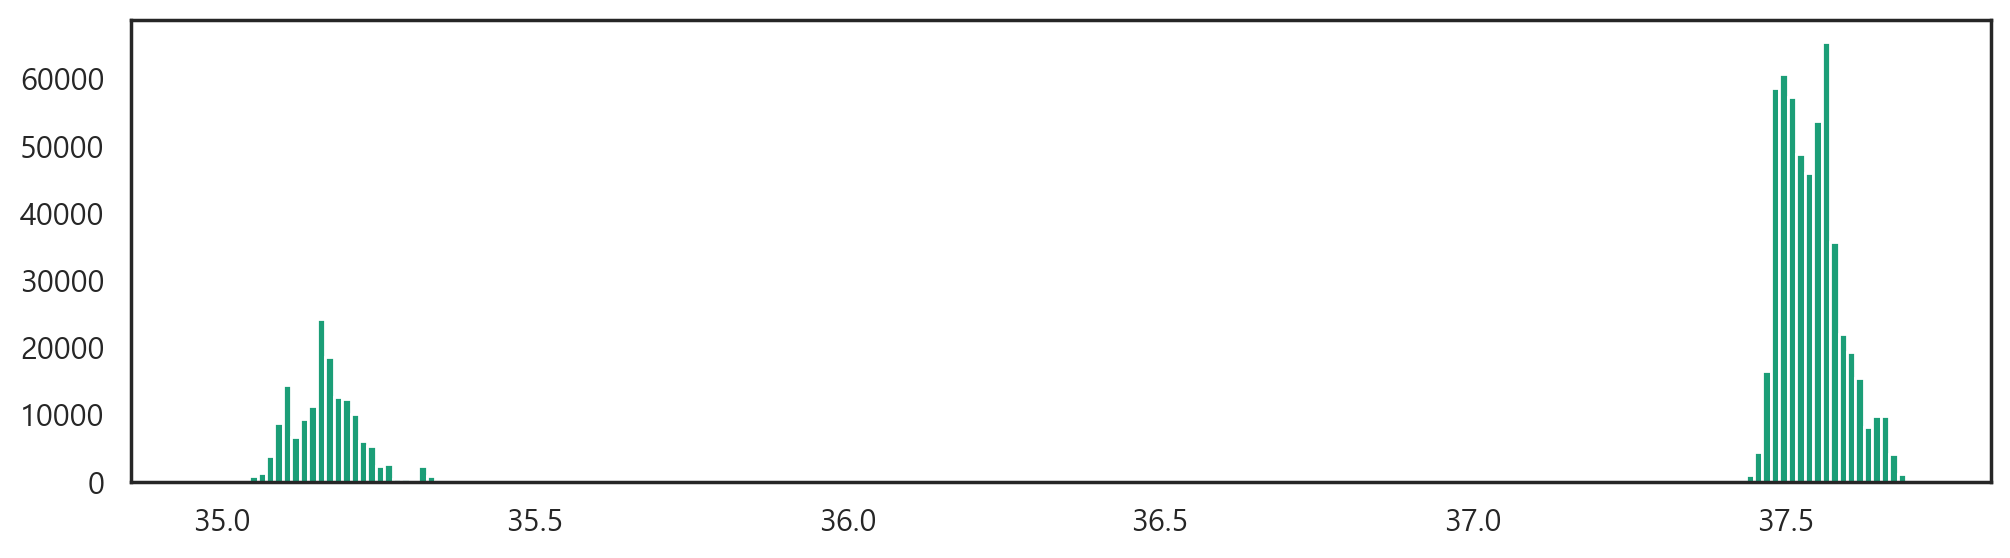

In [226]:
plt.hist(df['위도'],bins=200)
plt.show()

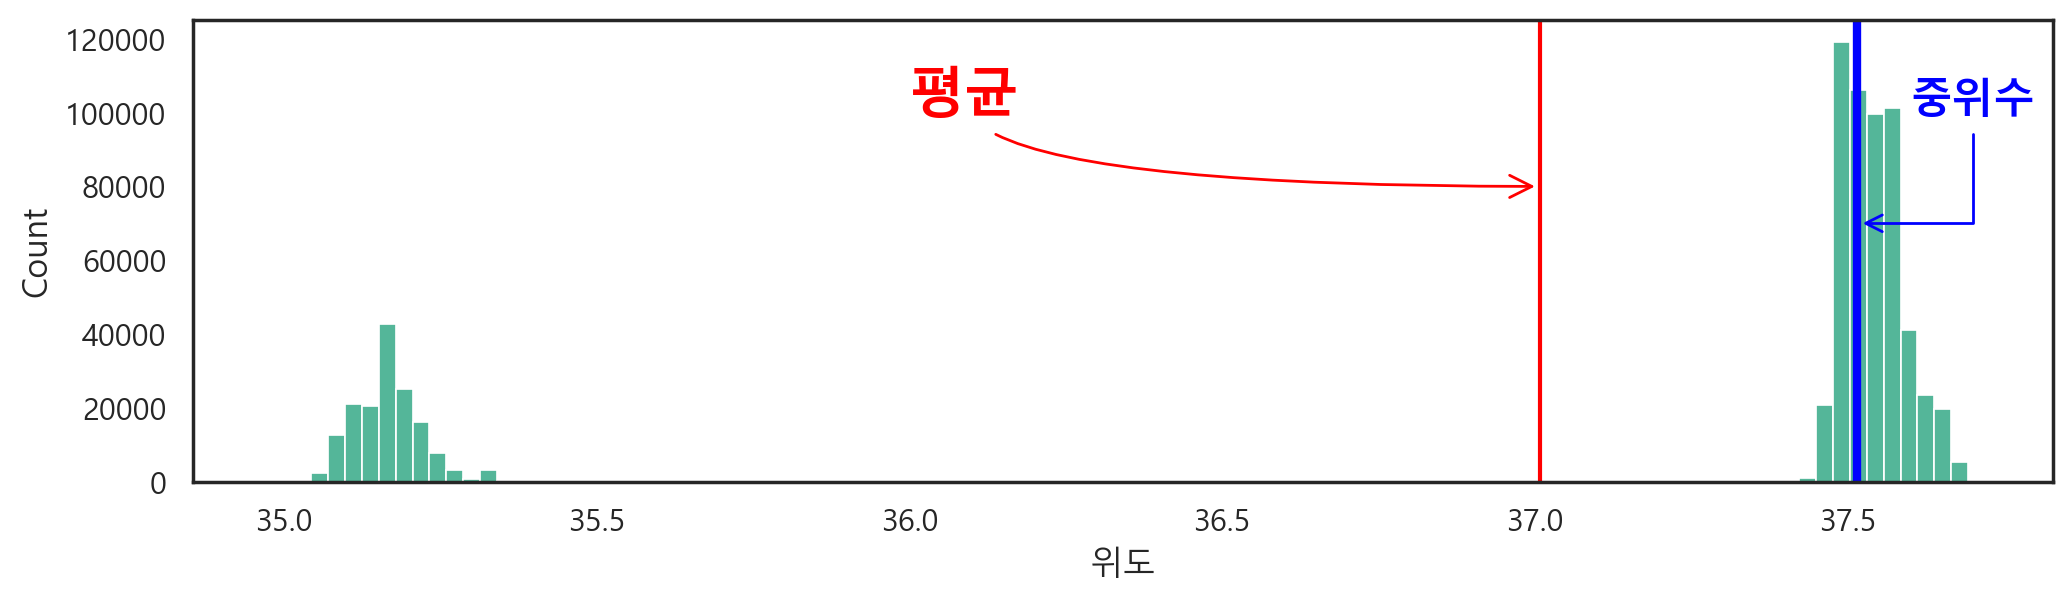

In [239]:
sns.histplot(data=df, x='위도', bins=100)
plt.axvline(df['위도'].mean(), color='r')
plt.annotate('평균',
            xytext=(36,100000), # 글자 위치
            xy = (df['위도'].mean(), 80000), # 화살표가 가리킬 좌표
            arrowprops={'arrowstyle':'->',
                       'connectionstyle':'angle3', # angle, arc, ..
                        'color':'r'},
            fontsize=20,
            weight='bold',
            color='r')
plt.axvline(df['위도'].median(), color='b', linewidth=3)
plt.annotate('중위수',
            xytext=(37.6, 100000),
            xy=(df['위도'].median(), 70000),
            arrowprops=dict(arrowstyle='->',
                           connectionstyle='angle',
                           color='b'),
            color='b',
            weight='bold',
            fontsize=15)
plt.show()

In [243]:
df['위도'].skew()

-1.3201510434921953

## ② 경도의 빈도표를 시각화 : plot.hist, hist, sns.displot, sns.histplot

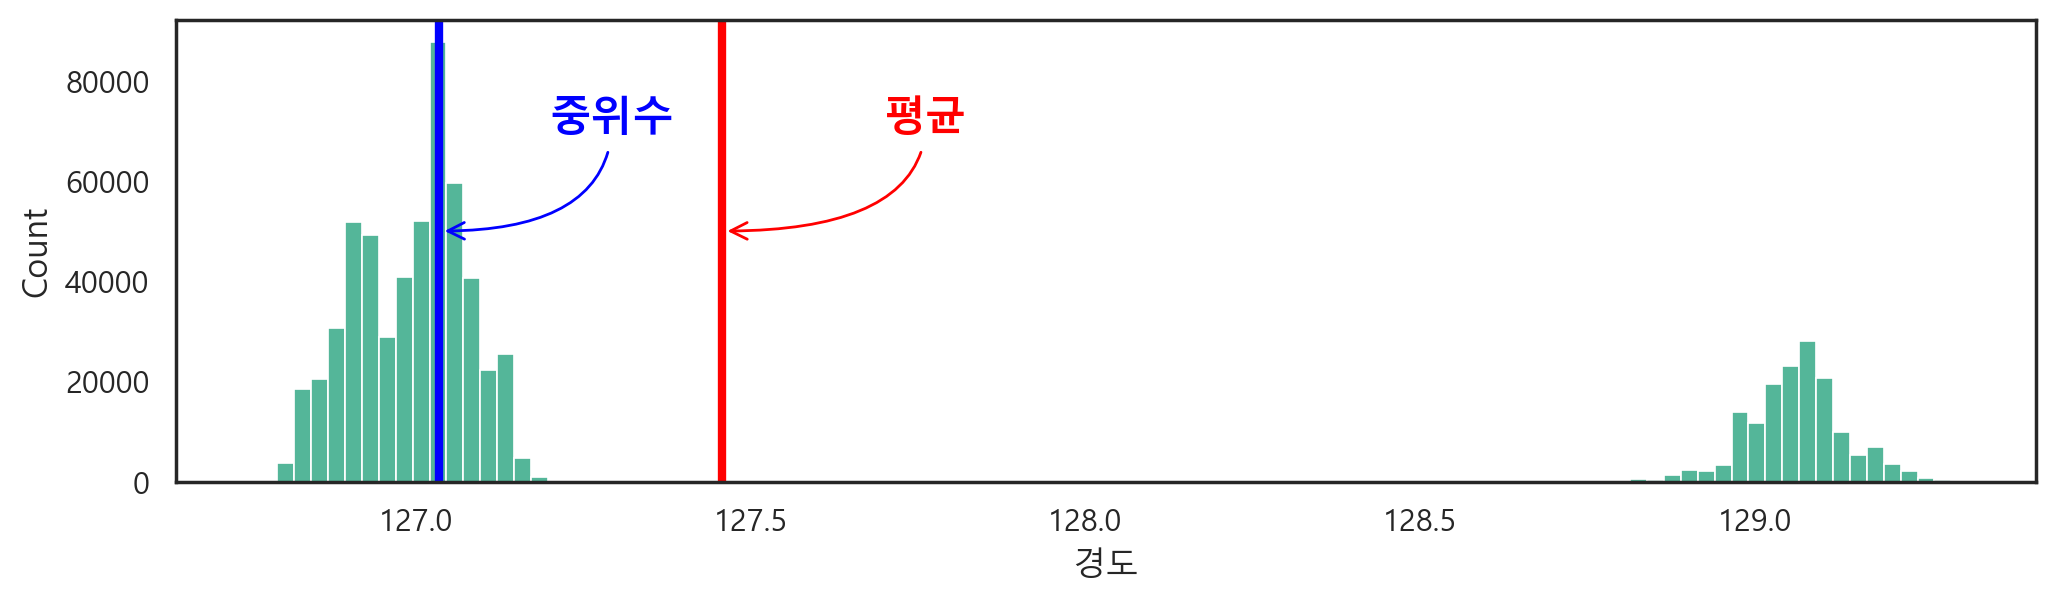

In [259]:
sns.histplot(data=df, x='경도', bins=100)
plt.axvline(df['경도'].mean(), color='r',linewidth=3)
plt.annotate('평균',
            xytext=(127.7,70000), # 글자 위치
            xy = (df['경도'].mean(), 50000), # 화살표가 가리킬 좌표
            arrowprops={'arrowstyle':'->',
                       'connectionstyle':'angle3', # angle, arc, ..
                        'color':'r'},
            fontsize=15,
            weight='bold',
            color='r')
plt.axvline(df['경도'].median(), color='b', linewidth=3)
plt.annotate('중위수',
            xytext=(127.2, 70000),
            xy=(df['경도'].median(), 50000),
            arrowprops=dict(arrowstyle='->',
                           connectionstyle='angle3',
                           color='b'),
            color='b',
            weight='bold',
            fontsize=15)
plt.show()

In [260]:
df['경도'].skew()

1.3043269016594654

# 8. 상관계수
-  두 변수 간에 어떤 선형적 관계를 갖고 있는 지를 분석하는 방법
- [상관 분석 - 위키백과, 우리 모두의 백과사전M](https://ko.wikipedia.org/wiki/상관_분석) 

- 결과의 해석 : r 값은 X 와 Y 가 완전히 동일하면 +1, 전혀 다르면 0, 반대방향으로 완전히 동일 하면 –1 을 가진다. 결정계수(coefficient of determination)는 $r^2$로 계산하며 이것은 X 로부터 Y를 예측할 수 있는 정도를 의미한다.
- ([수학기호 사이트 참조](https://matplotlib.org/2.0.2/users/mathtext.html))

- 일반적으로
    * r이 -1.0과 -0.7 사이이면, 강한 음적 선형관계,
    * r이 -0.7과 -0.3 사이이면, 뚜렷한 음적 선형관계,
    * r이 -0.3과 -0.1 사이이면, 약한 음적 선형관계,
    * r이 -0.1과 +0.1 사이이면, 거의 무시될 수 있는 선형관계,
    * r이 +0.1과 +0.3 사이이면, 약한 양적 선형관계,
    * r이 +0.3과 +0.7 사이이면, 뚜렷한 양적 선형관계,
    * r이 +0.7과 +1.0 사이이면, 강한 양적 선형관계로 해석한다.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/d/d4/Correlation_examples2.svg/1280px-Correlation_examples2.svg.png" width="600">

이미지 출처 : [위키백과](https://ko.wikipedia.org/wiki/상관_분석)


## ① 전체 숫자 컬럼끼리의 상관계수

In [264]:
corr=df.corr(numeric_only=True)

## ②	상관계수를 이용하여 heatmap 시각화
- 참조 http://seaborn.pydata.org/examples/many_pairwise_correlations.html 

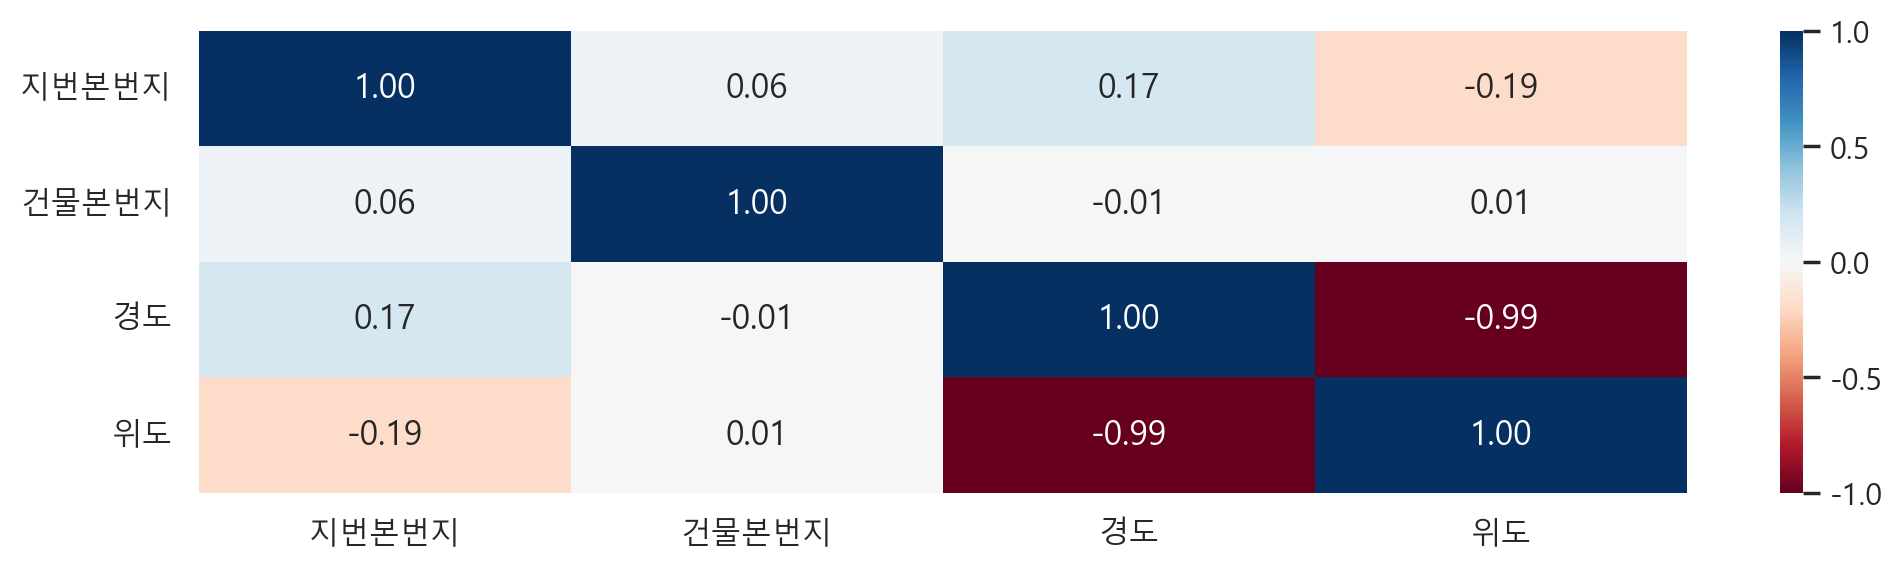

In [266]:
sns.heatmap(corr,annot=True,fmt='.2f',cmap='RdBu',vmin=-1,vmax=1)
plt.show()

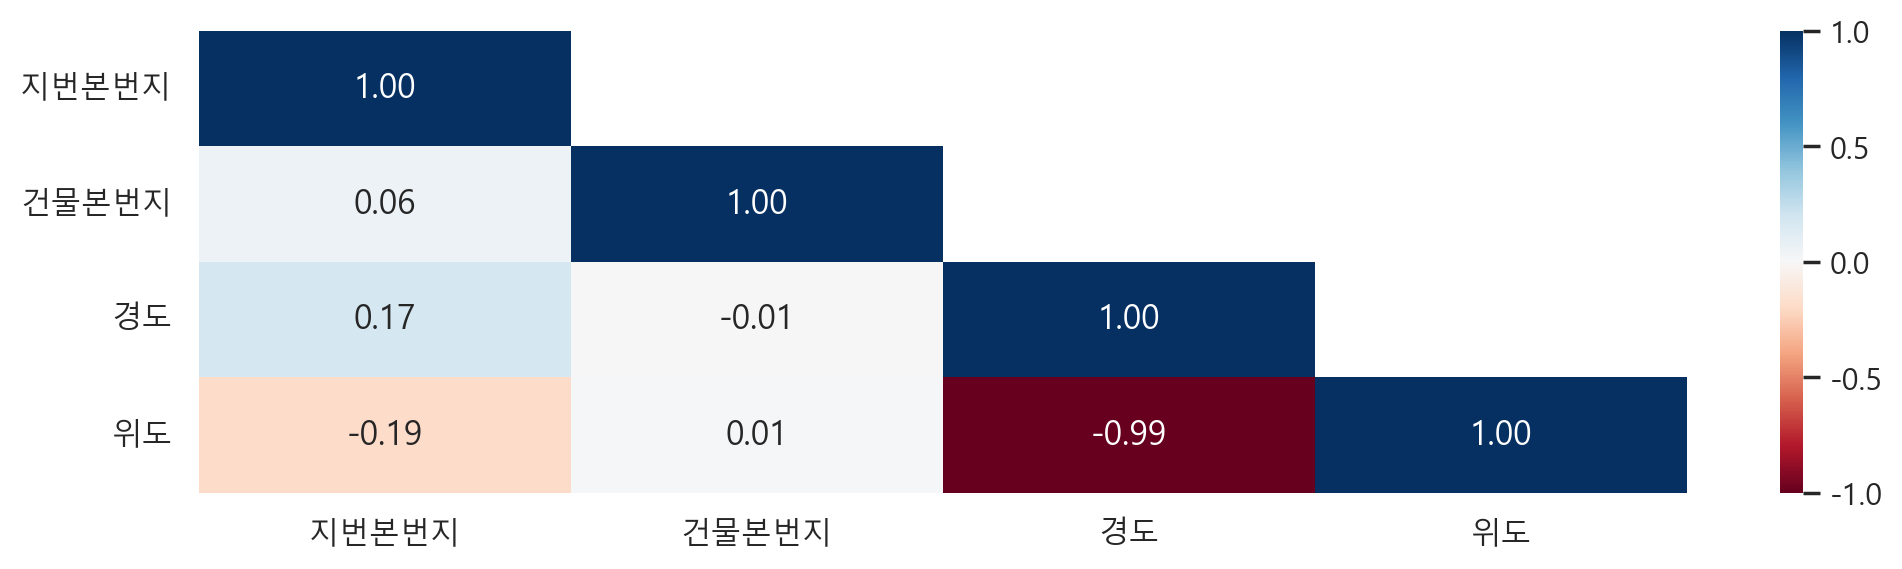

In [269]:
mask = np.triu(np.ones_like(corr, dtype=bool),k=1) #k=1 가운데 111111 포함시킴
sns.heatmap(corr,annot=True,fmt='.2f',cmap='RdBu',vmin=-1,vmax=1,mask=mask)
plt.show()

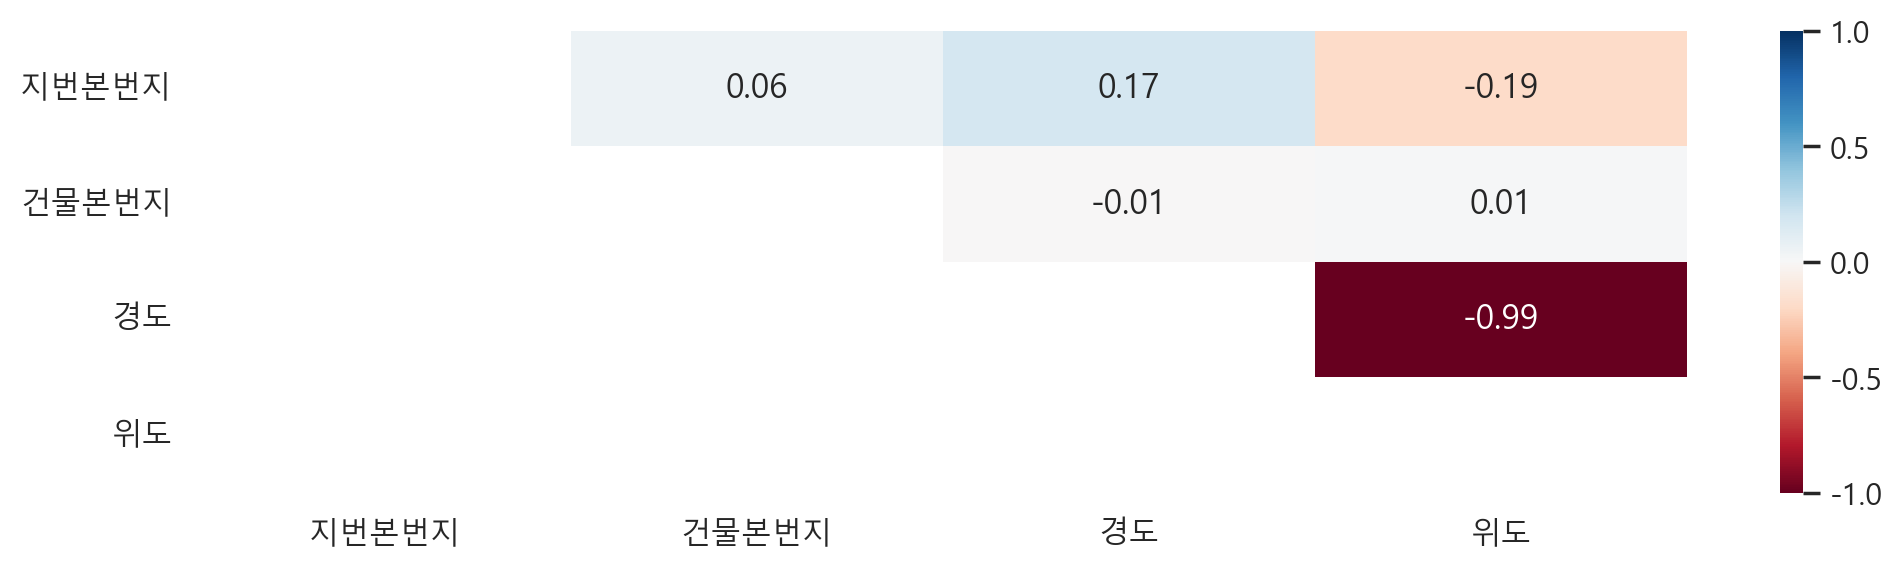

In [270]:
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr,annot=True,fmt='.2f',cmap='RdBu',vmin=-1,vmax=1,mask=~mask)
plt.show()

# 9.	경도와 위도 컬럼을 이용하여 산점도

[Anscombe’s quartet — seaborn 0.10.0 documentation](https://seaborn.pydata.org/examples/anscombes_quartet.html)

## ①	X축에는 경도, y축에는 위도 컬럼을 산점도로 시각화

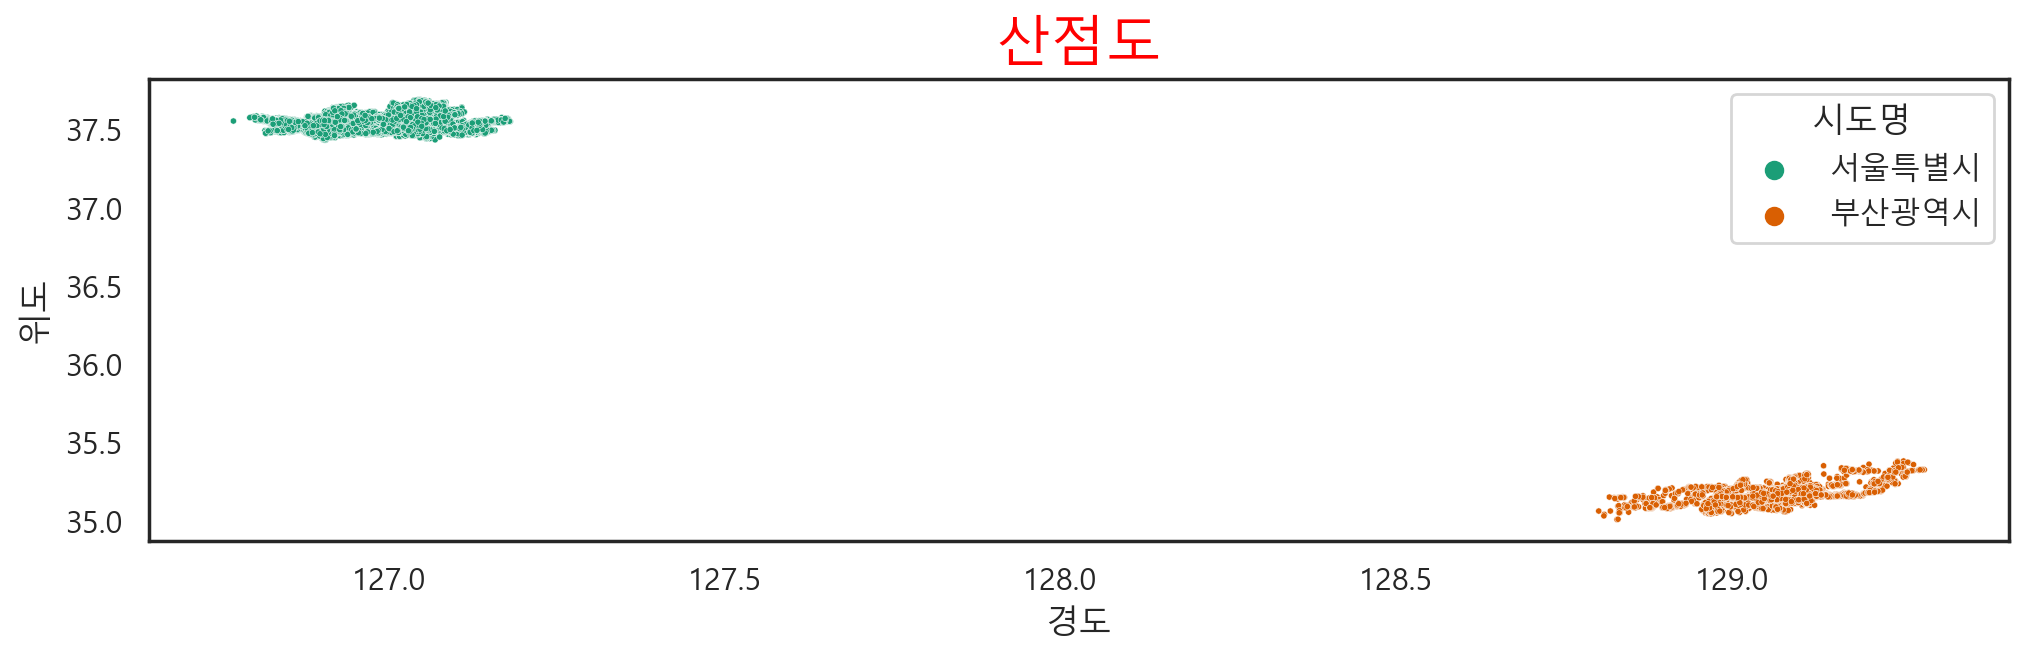

CPU times: total: 2.73 s
Wall time: 2.71 s


In [281]:
%%time
g=sns.scatterplot(data=df.sample(frac=0.1), x='경도', y='위도', s=5,hue='시도명')
g.set_title('산점도',color='r',fontsize=20)
plt.title('산점도',color='r',fontsize=20)
plt.show()


## ②	경도와 위도의 산점도를 “시도명” 컬럼별로 서브플롯으로 시각화

In [282]:
df['시도명'].unique()

array(['서울특별시', '부산광역시'], dtype=object)

CPU times: total: 906 ms
Wall time: 911 ms


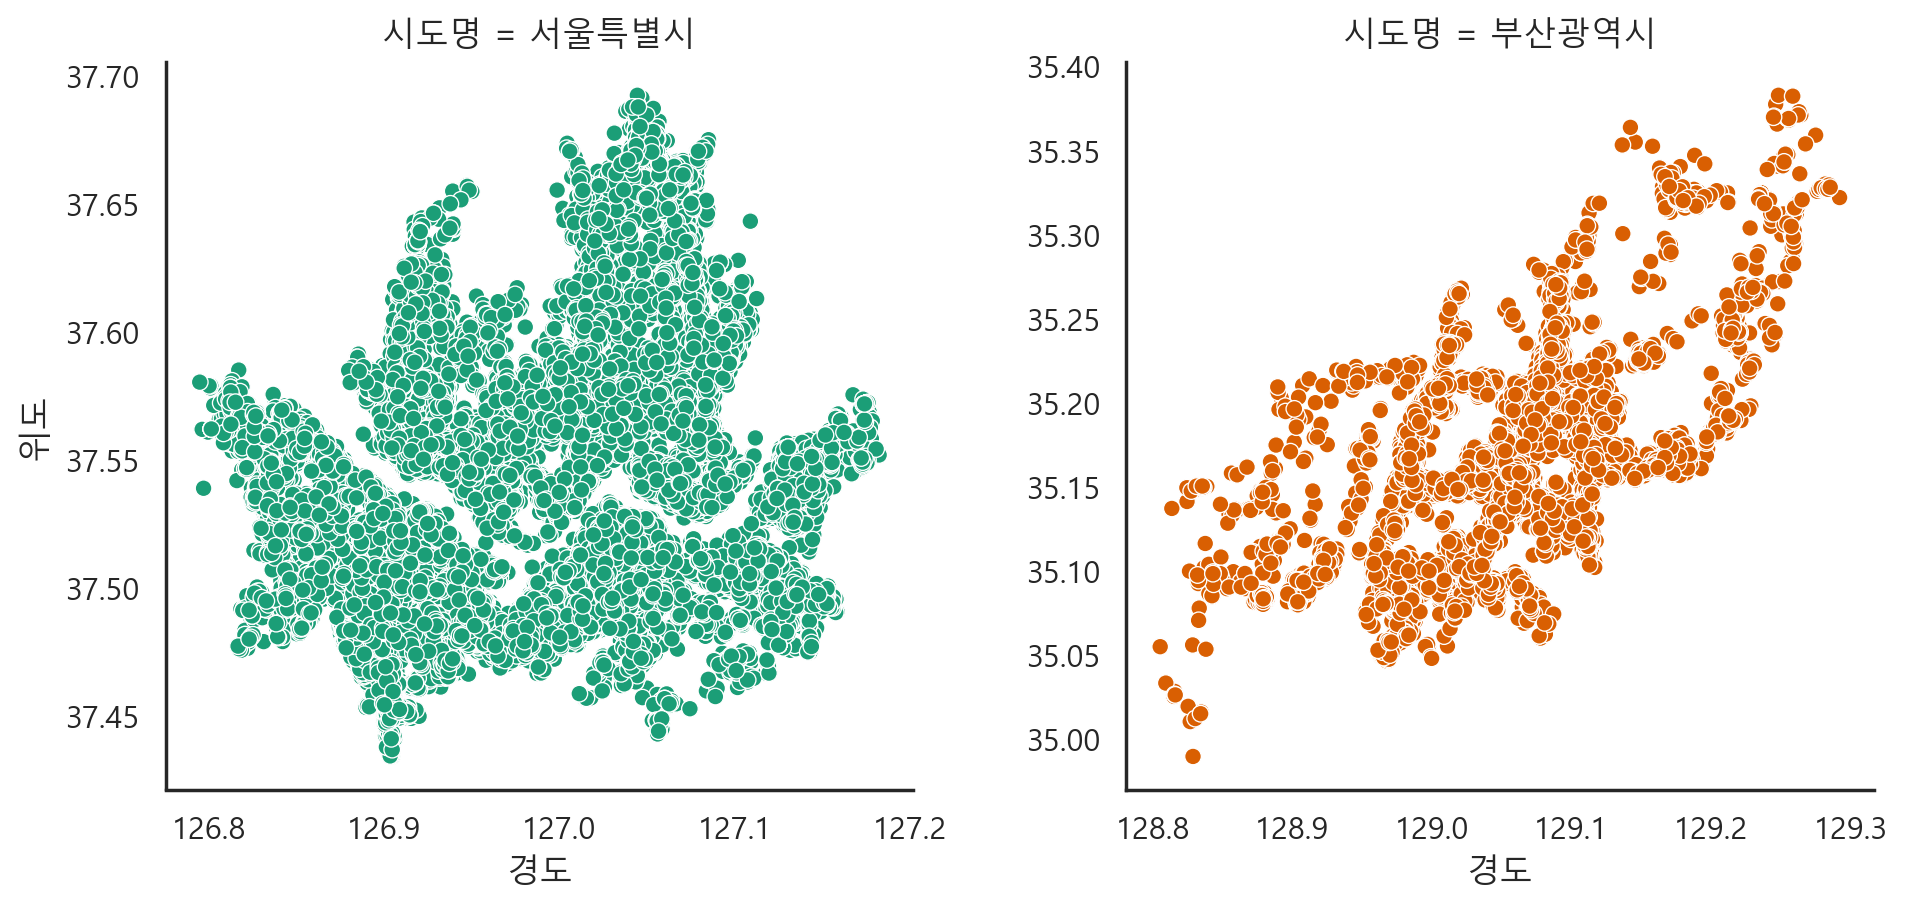

In [289]:
%%time
g= sns.relplot(data=df.sample(frac=0.1), x='경도',y='위도',hue='시도명',col='시도명',
              kind='scatter', facet_kws={'sharey':False,'sharex':False},
              height=4, #높이(인치)
              aspect=1,
              legend=False,
              col_order=['서울특별시','부산광역시'] # 서브플롯의 순서
              )

g.fig.set_size_inches(10,5)
plt.tight_layout()
plt.show

## ③ 위의 1번에서 시각화된 산점도를 바탕으로 회귀선을 그린다.

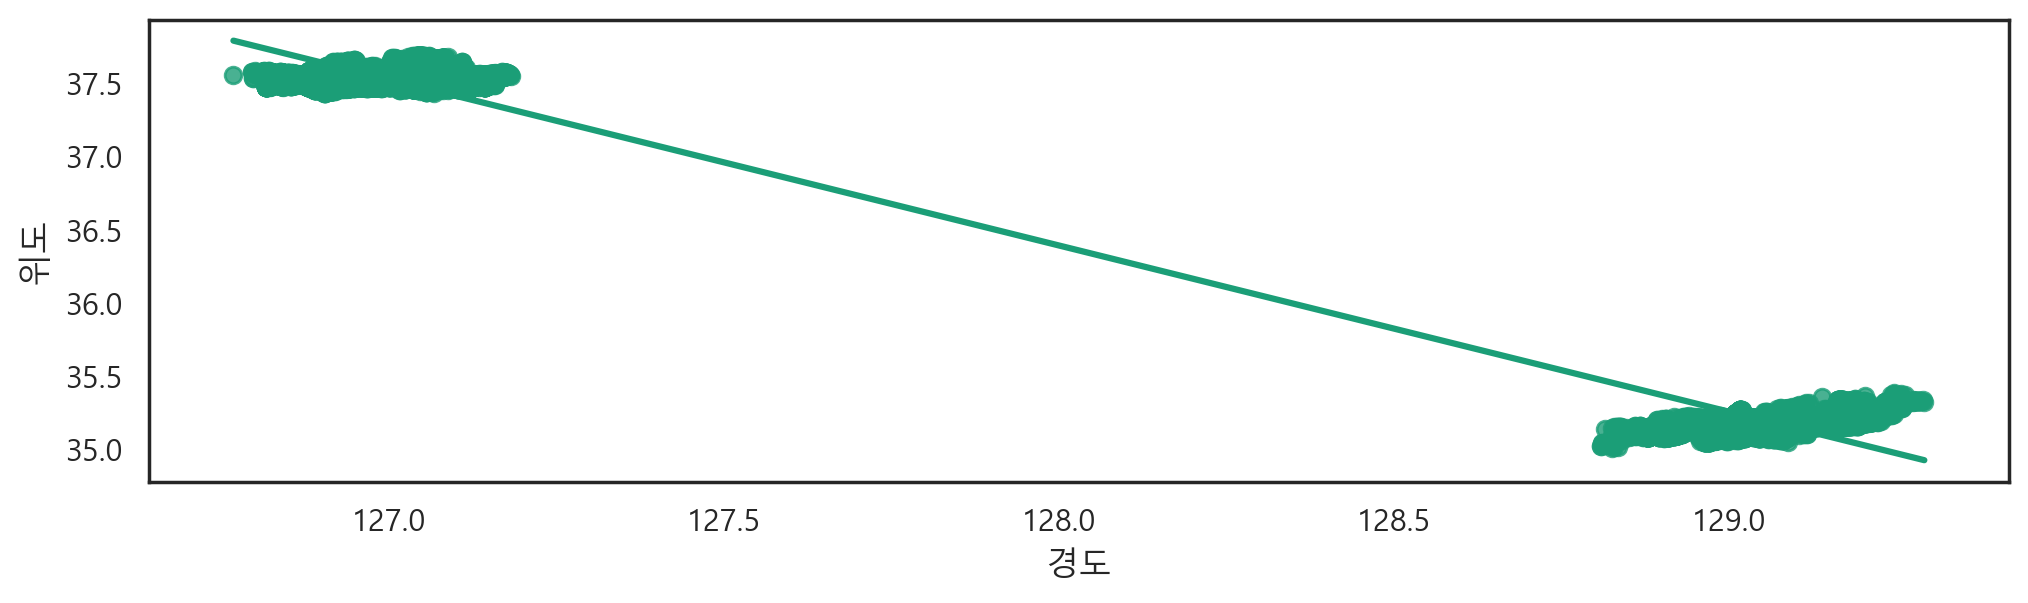

In [292]:
g=sns.regplot(data=df.sample(frac=0.1), x='경도', y='위도')
plt.show()


## ④ 위의 2번에서 시각화된 산점도를 바탕으로 회귀선을 서브 플롯으로 그린다.

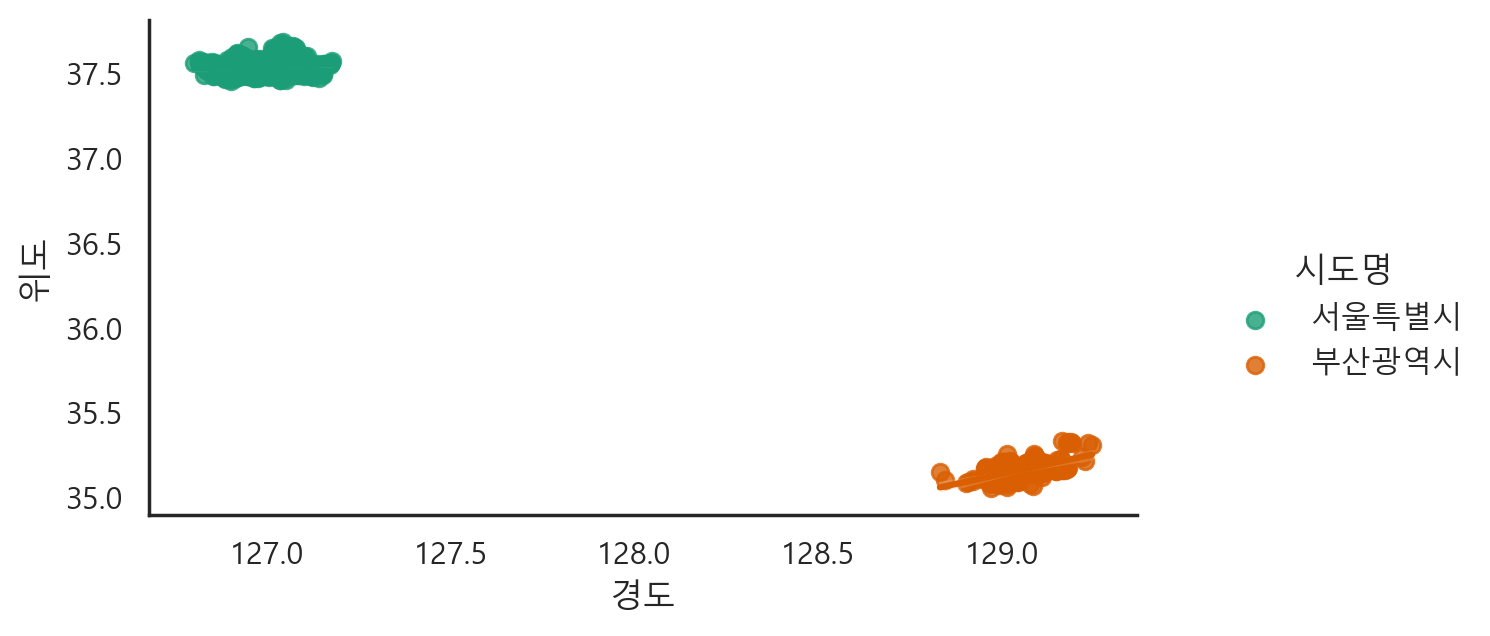

In [295]:
g=sns.lmplot(data=df.sample(frac=0.001), x='경도', y='위도',hue='시도명')
g.fig.set_size_inches(8,3)
plt.show()

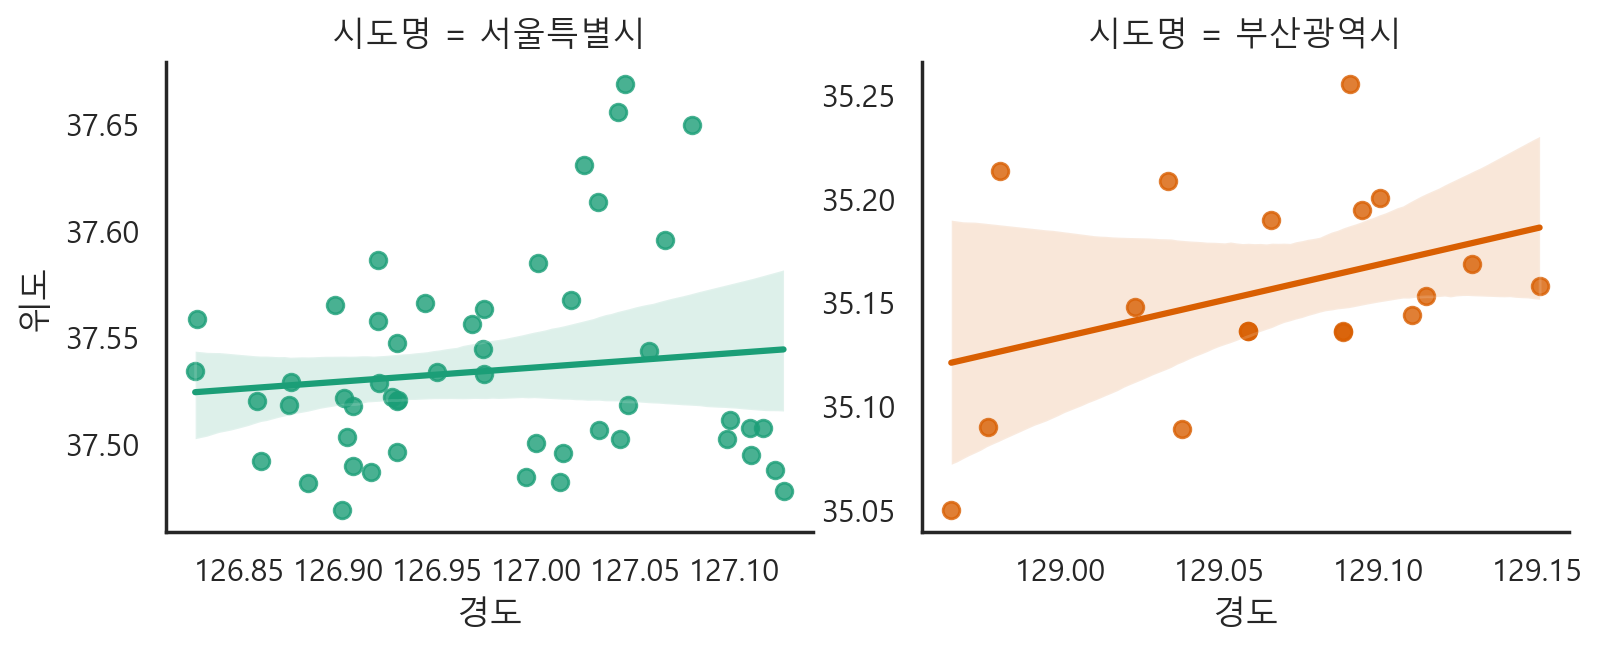

In [300]:
g=sns.lmplot(data=df.sample(frac=0.0001), x='경도', y='위도',hue='시도명',col='시도명',facet_kws={'sharey':False,'sharex':False})
g.fig.set_size_inches(8,3)
plt.show()

# 10. 상권업종대분류명별 상호명의 개수를 도출하고 시각화하기

# 11. 상권업종대분류명이 음식인 서브셋을 이용한 분석
## ① “상권업종대분류명”이 음식인 서브셋을 변수 df_food에 할당하고 확인


## ②	“상권업종대분류명”이 음식이면서, "시군구명”이 강남구 데이터만 가져와 “상권업종중분류명”별로 빈도수를 구함(loc함수를 이용 vs loc함수 이용안함)

# 12.df 데이터셋에서 “상권업종대분류명”이 음식인 데이터 중 서울특별시 데이터 서브셋
- https://seaborn.pydata.org/tutorial/categorical.html : 범주형그래프
## ①	“상권업종대분류명”이 음식인 서브셋 중 서울특별시 데이터만 변수 df_seoul_food에 할당하고 확인


## ② df_seoul_food 데이터 셋을 시군구명, 상권업종중분류명으로 그룹화하여 상점수를 count한 내용을 food_gu 변수에 할당. 

## ③ df_seoul_food_gu 변수를 표로 출력(df_seoul_food_gu 이용하여 unstack).

## ④ 위 3번 스타일의 표를 pivot_table함수를 이용하여 출력

## ⑤ 3번의 결과 중 강남구 데이터만 뽑아 barplot으로 시각화(판다스 plot이용)

## ⑥ 3번 df_seoul_food_gu를 seaborn을 이용하여 구별 음식점 상호 개수를 시각화

## ⑦ 상권업종중분류명별 음식점 상호갯수

## ⑧	Seaborn의 catplot을 이용하여 상권업종중분류별 음식점을 구별로 시각화(서브플롯으로 시각화)

https://seaborn.pydata.org/tutorial/categorical.html

## ⑨	Seaborn의 catplot을 이용하여 구별 음식점을 상권업종중분류명별로 서브 플롯으로 시각화

# 13.	구별로 학원수 비교 : 서울 대치동이나 목동에 사교육이 발달되었다는 가설을 뒷받침할 수 있는 분석
## ① 서울시 교육(상권업종대분류명 이용) 데이터를 df_academy 변수에 할당하고 확인


## ②	df_academy 데이터 셋을 상호명별로 빈도수 출력(value_counts()함수 이용하거나 groupby이용)

## ③ df_academy 데이터 셋을 상호명별로 빈도수 상위 10개 출력

## ④ df_academy 데이터 셋을 시군구명 별로 빈도수 출력(학원이 가장 많은 구부터 출력)

## ⑤df_academy 데이터 셋에서 어떤 종류의 학원들이 많은지 상위10개만 academy_count변수에 할당하고 출력(상권업종소분류명 컬럼 이용)

## ⑥ df_academy 데이터셋에서 상권업종소분류명별로 빈도수를 구했을 때 빈도가 1000이상인 데이터만 따로 academy_count_1000변수에 할당

## ⑦ df_academy 데이터셋을 “시군구명”, "상권업종소분류명” 별 상호명 빈도수를 academy_group 변수에 할당 출력

## ⑧ academy_group 데이터셋에서 강남구 데이터만 출력 및 시각화(barplot)

## ⑨ df_academy데이터 중 “법정동명”컬럼이 “대치동”과 “목동”인 데이터만 가져와 상권업종소분류명별 빈도수 출력

## ⑩“상권업종소분류명”별 "시군구명” 별 상호명 빈도수를 g변수에 할당하고 출력

## ⑪ g변수의 내용중 "상권업종소분류명” 컬럼이 “입시·교과학원”데이터만 시각화(pandas의 plot.bar, pandas의 barh, seaborn의 barplot)

# 14. 서울시 데이터만 경도와 위도를 산점도로 시각화
## ① df_academy 데이터셋의 경도와 위도를 “시군명”별로 색상을 다르게 scatterplot으로 시각화


https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot : 범례사용

## ② df_academy 데이터셋의 경도와 위도를 “상권업종소분류명”별로 색상을 다르게 scatterplot으로 시각화

## ③ df_academy 데이터셋 중 “입시·교과학원” 데이터만, 경도와 위도를 “시군구명”별로 색상을 다르게 scatterplot으로 시각화

## ④ df_academy 데이터셋 중 “태권도/무술학원” 데이터만, 경도와 위도를 “시군명”별로 색상을 다르게 scatterplot으로 시각화

## ⑤ df_academy 데이터셋 중 “입시·교과학원” 데이터와 “태권도/무술학원” 데이터만, 경도와 위도를 “상권업종소분류명”별로 색상을 다르게 scatterplot으로 시각화

# 15. 지도시각화 : Folium
` 아나콘다 프롬프트에서 아래의 둘 중 하나를 실행`

`pip install folium`

`conda install -c conda-forge folium`

-	docs : https://python-visualization.github.io/folium/latest/getting_started.html?utm_source=chatgpt.com
-	Quickstart : https://python-visualization.github.io/folium/version-v0.9.1/quickstart.html?utm_source=chatgpt.com


In [ ]:
# 태권도/무술학원과 입시·교과학원을 분리해서 지도 시각화